# Bulldozer Sale Price Prediction
This project is from the [Kaggle Bluebook for Bulldozers competition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/overview)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestRegressor
# from pandas.api.types import CategoricalDtype

## Problem Definition
Predicting Bulldozer sale price based on history data
* Since we are predicting the future sale price of the item, it is defined as a regression problem 

## Data
Data is downloaded from [Kaggle](https://www.kaggle.com/competitions/bluebook-for-bulldozers/data)

* Train.csv is the training set, which contains data through the end of 2011.
* Valid.csv is the validation set, which contains data from January 1, 2012 - April 30, 2012
* Test.csv is the test set, which contains data from May 1, 2012 - November 2012.

In [2]:
train_df = pd.read_csv("data/Train.csv")
valid_df = pd.read_csv("data/Valid.csv")
test_df = pd.read_csv("data/Test.csv")

/var/folders/mf/3wt3q1y17_3fr_j24qtf31bm0000gn/T/ipykernel_48569/1727769340.py:1: DtypeWarning: Columns (0: fiModelSeries, 1: Coupler_System, 2: Grouser_Tracks, 3: Hydraulics_Flow) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("data/Train.csv")


In [3]:
train_df.shape, valid_df.shape, test_df.shape

((401125, 53), (11573, 52), (12457, 52))

**Our dataset contains:**

Training data: 401125 entries

Valid data: 11573 records

Test data: 12457 observations

In [4]:
train_df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='str')

**'SalePrice'** is our target, and the others are features

In [5]:
# Have a glance of the dataset
train_df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Evaluation
The evaluation [metric for this this competition](www.kaggle.com/competitions/bluebook-for-bulldozers/overview/evaluation) is **RMSE**(root mean squared log error) between the actual and predicted auction price.

## Feature

* There is a data Dictionary provided by [the competition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/data)  

In [6]:
print(f"We have {len(train_df.columns)-1} features in our training dataset") # minus our target (i.e. SalePrice)

We have 52 features in our training dataset


## 1. Exploratory Data Analysis

In [7]:
# Check data types
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 401125 entries, 0 to 401124
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   401125 non-null  int64  
 1   SalePrice                 401125 non-null  int64  
 2   MachineID                 401125 non-null  int64  
 3   ModelID                   401125 non-null  int64  
 4   datasource                401125 non-null  int64  
 5   auctioneerID              380989 non-null  float64
 6   YearMade                  401125 non-null  int64  
 7   MachineHoursCurrentMeter  142765 non-null  float64
 8   UsageBand                 69639 non-null   str    
 9   saledate                  401125 non-null  str    
 10  fiModelDesc               401125 non-null  str    
 11  fiBaseModel               401125 non-null  str    
 12  fiSecondaryDesc           263934 non-null  str    
 13  fiModelSeries             56908 non-null   object 
 14 

Seems like we have plenty of missing values. Also, some data types need to be transformed as regression models accepts numerical values exclusively.

count    401125.000000
mean      31099.712848
std       23036.898502
min        4750.000000
25%       14500.000000
50%       24000.000000
75%       40000.000000
max      142000.000000
Name: SalePrice, dtype: float64


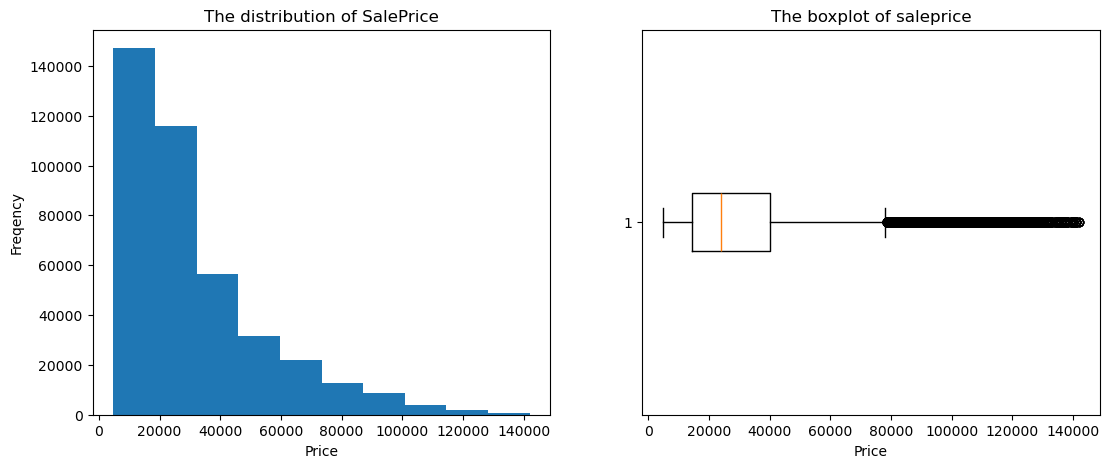

In [8]:
# Check Saleprice (our target)

print(train_df['SalePrice'].describe())

fig, (ax0, ax1) = plt.subplots(figsize = (13, 5),
                      nrows = 1,
                      ncols = 2)
ax0.hist(x = train_df['SalePrice'])
ax0.set(title = "The distribution of SalePrice",
       xlabel= "Price",
       ylabel= "Freqency");

ax1.boxplot(train_df['SalePrice'],
           orientation = 'horizontal')
ax1.set(title = "The boxplot of saleprice",
       xlabel = 'Price');

The distribution of Saleprice is right skewed. 

Majority price falls between around 20000 and 40000.

### Subsequently, features will be explored.

In [9]:
train_df['datasource'].value_counts()

datasource
132    260752
136     75491
149     26304
121     23979
172     14599
Name: count, dtype: int64

It turns out that there are 5 data source.

I suspect this feature matters much for the model.

Let's have a glance the relationpship between them by visulisation

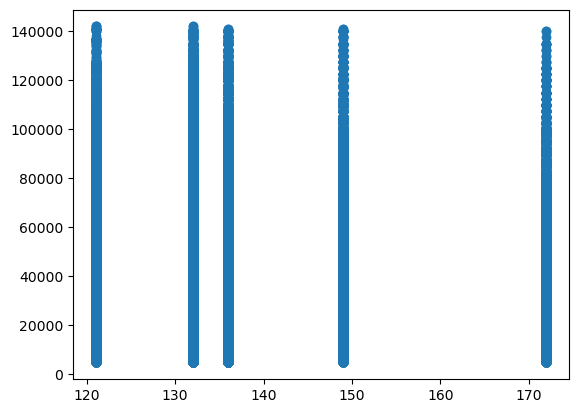

In [10]:
fig, ax = plt.subplots()
ax.scatter(train_df['datasource'],
          train_df['SalePrice']);

The scatter plot turns out indicates there is no strong correlation between `datasource` and `SalePrice`

* SalesID, MachineID, ModelID, auctioneerID are different identifiers.
    * Except for ModelID, the other IDs are unlikely to significantly affect our model. However, it needs to be verivied, so we will conduct a feature importance analysis to check whether this hypothesis holds true.
    * According to data dictionary, **ModelID** is associated with **fiModelDesc**. Thus, one of them could be dropped.
* Base on the data dictionary, **fiModelDesc** is Description of a unique machine model (see ModelID); concatenation of fiBaseModel & fiSecondaryDesc & fiModelSeries & fiModelDescriptor. Thus, 

In [11]:
# # Checking if fiModelDesc can be represented by ModelID
# # The result is correct

# n_rows = 5
# for _ in train_df['ModelID'].unique():
#     print(f"ModelID : {_}")
#     print(train_df[train_df['ModelID'] == _]['fiModelDesc'].head(n_rows))

fiModelDesc is checked that it can be represented by ModelID (see above cell)
I wanted to keep ModelID, and drop fiModelDesc. 

However, per data dictionary, the feature 'fiModelDesc' is concatenated by fiBaseModel & fiSecondaryDesc & fiModelSeries & fiModelDescriptor, so let me check how does the concatenation work.

In [12]:
# Checking the associateion among ModelID, 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelSeries', and 'fiModelDescriptor'
train_df[['ModelID', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelSeries', 'fiModelDescriptor' ]]

,ModelID,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelSeries,fiModelDescriptor
0,3157,521D,521,D,NaN,NaN,NaN
1,77,950FII,950,F,II,II,NaN
2,7009,226,226,NaN,NaN,NaN,NaN
3,332,PC120-6E,PC120,NaN,-6E,-6E,NaN
4,17311,S175,S175,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
401120,21439,35NX2,35,NX,2,2,NaN
401121,21439,35NX2,35,NX,2,2,NaN
401122,21439,35NX2,35,NX,2,2,NaN
401123,21435,30NX,30,NX,NaN,NaN,NaN


ModelID appears to function as an encoder that represents fiModelDesc, which is formed by concatenating fiBaseModel, fiSecondaryDesc, fiModelSeries, and fiModelDescriptor.
Therefore, I decide to drop 'fiModelDesc', ‘fiBaseModel’, ‘fiSecondaryDesc’, ‘fiModelSeries’, and ‘fiModelDescriptor’ to avoid redundancy.

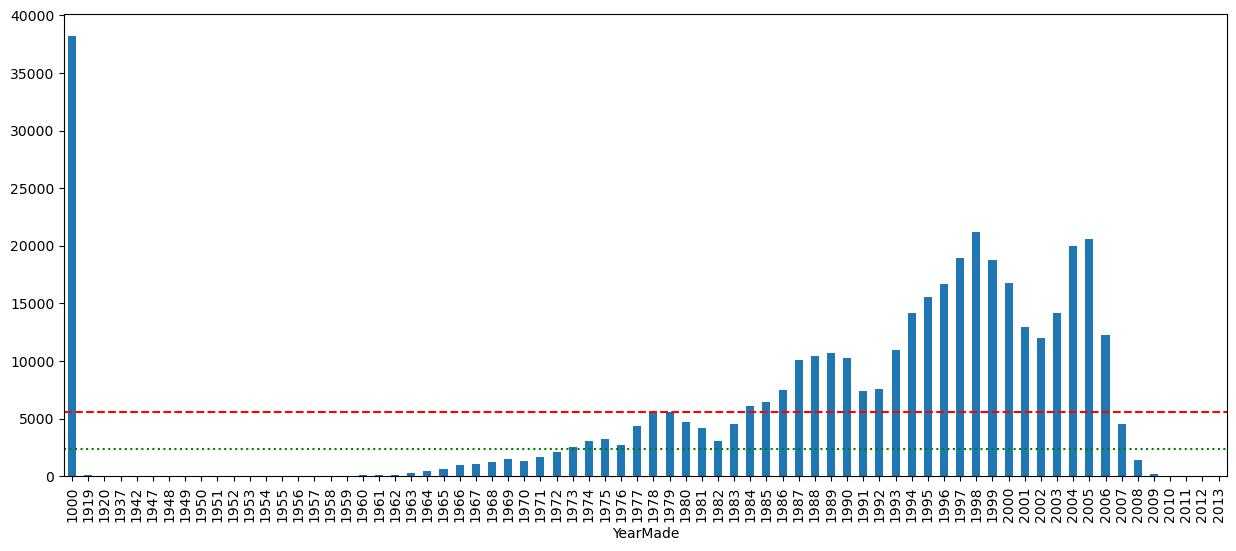

In [13]:
# Checking yearMade

fig = plt.figure(figsize = (15, 6))
fig = train_df['YearMade'].value_counts().sort_index().plot.bar()
plt.axhline(np.mean(train_df['YearMade'].value_counts()),
           linestyle = '--',
           c = 'red')
plt.axhline(np.median(train_df['YearMade'].value_counts()),
           linestyle = ':',
           c = 'green')

In [14]:
print(f"The proportion of products manufactured in the year 1000 is:  {train_df[train_df['YearMade'] == 1000].shape[0] /  train_df['YearMade'].shape[0] * 100:.2}%")

The proportion of products manufactured in the year 1000 is:  9.5%


The above bar graph provides several key insights as below:
1. Most products were made in the year 1000, which is abnormal.
2. Following the year 1000, 1999 is the second most common manufacture year.
3. The most manufacturing years occur in cycles of 10 to 15 years, with peaks in 1978, 1989, 1998, and 2005.

Let's explore the replationship between `YearMade` and `SalePrice`

<Axes: xlabel='YearMade'>

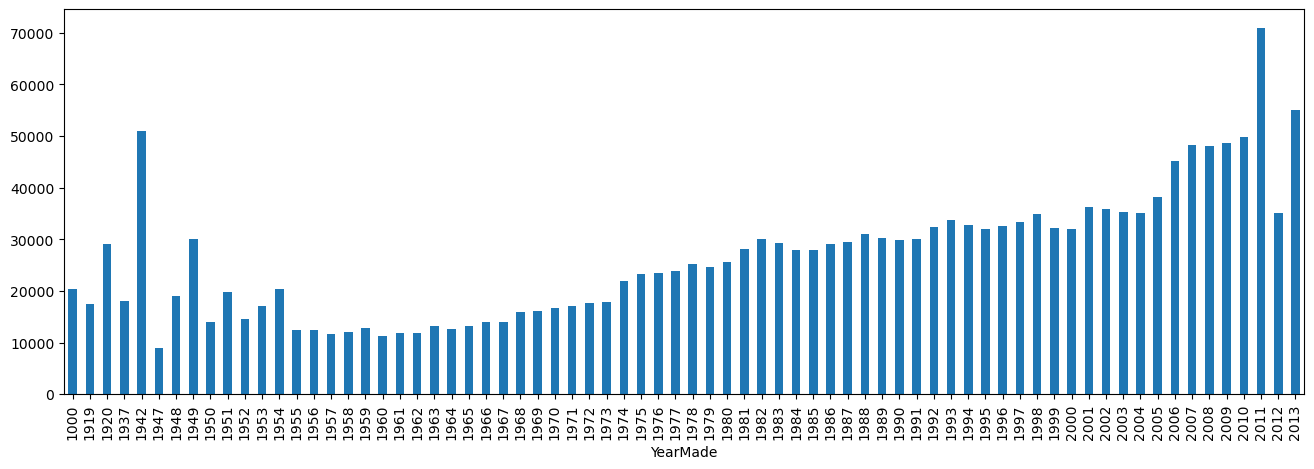

In [15]:
# Relationship between YearMade and SalePrice

train_df[train_df['YearMade'] == 1000]

train_df.groupby(["YearMade"]).mean(numeric_only = True).sort_values(by = "YearMade")['SalePrice'].plot.bar(figsize = (16, 5))

The bar graph shows the positive relationship between `YearMade` and `SalePrice`, which is also our target. The `SalePrice` increases with the bulldozer's manufacturing year.
Notably, 1942 shows the second-highest sale price, which is an unexpected peak.

Regarding the manufacturing year 1000, according to [this article](https://sitechrockymtn.com/blog/a-history-of-the-bulldozer/), it is apparetly recorded incorrectly as the first modern bulldozer was designed in 1923, and built in 1925. Thus, I may replace the year by inferring it from other entries with the same ModelID or simply fill it with `na` in the **Data pre-processing seccion**

**MachineHoursCurrentMeter:** 

current usage of the machine in hours at time of sale (saledate);  null or 0 means no hours have been reported for that sale

In [16]:
print(f"Missing values account for {(train_df[train_df['MachineHoursCurrentMeter'] == 0].shape[0] +  train_df['MachineHoursCurrentMeter'].isna().sum())/ train_df['MachineHoursCurrentMeter'].shape[0] * 100 :.2f} %")

Missing values account for 82.64 %


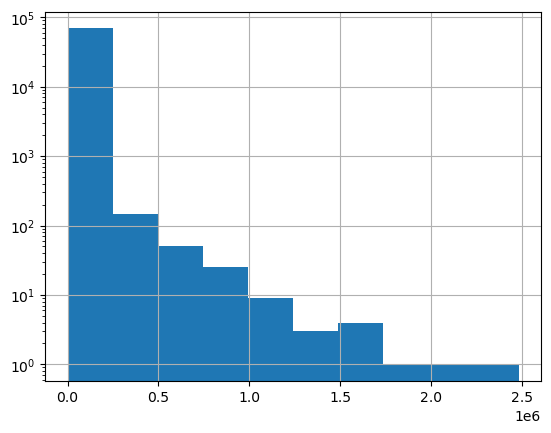

In [17]:
train_df[train_df['MachineHoursCurrentMeter'] > 0]['MachineHoursCurrentMeter'].hist(log = True);

Proportion of missing values in UsageBand : 82.64 %


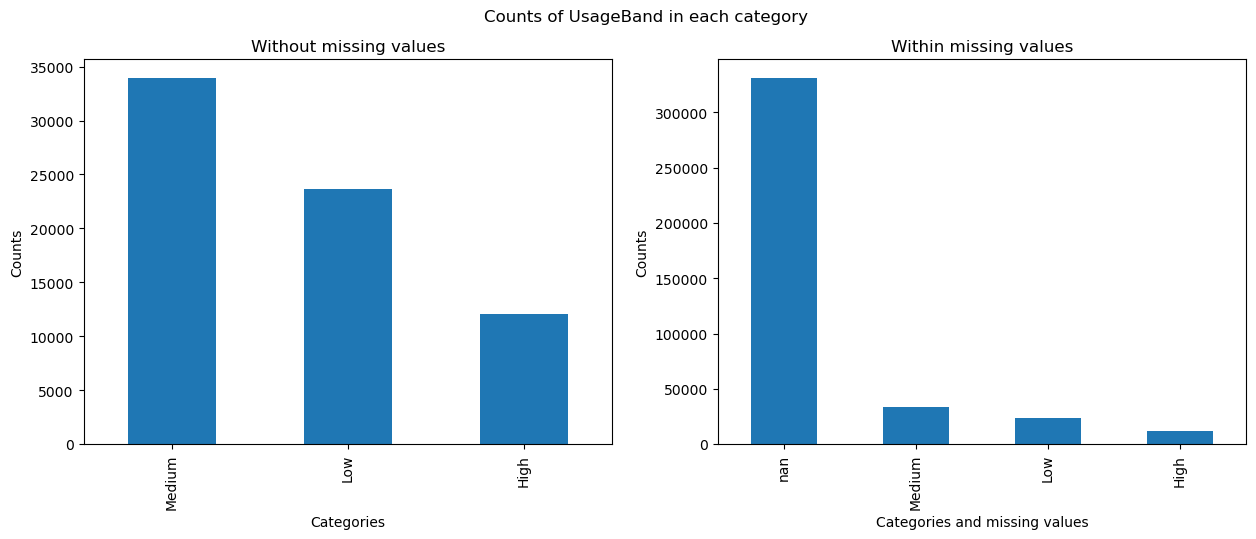

In [18]:
print(f"Proportion of missing values in UsageBand : { train_df['UsageBand'].isna().sum() / train_df.shape[0] * 100 :.2f} %")

fig, (ax0, ax1) = plt.subplots(figsize = (15, 5),
                              nrows = 1,
                              ncols = 2)

train_df['UsageBand'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "Without missing values",
       xlabel= "Categories",
       ylabel = "Counts")

train_df['UsageBand'].value_counts(dropna=False).plot.bar(ax = ax1)
ax1.set(title = "Within missing values",
        xlabel = "Categories and missing values",
        ylabel = "Counts")

fig.suptitle("Counts of UsageBand in each category");

In [19]:
False in train_df['UsageBand'].isna() == train_df['MachineHoursCurrentMeter'].isna()

# Seems like they share the same missing vlaues

False

In [20]:
pd.crosstab(train_df['UsageBand'], train_df['fiBaseModel'])

fiBaseModel,10,1080,1088,110,1105,112,115,1150,12,120,...,ZX350,ZX370,ZX450,ZX460,ZX50,ZX600,ZX70,ZX75,ZX80,ZX800
UsageBand,,,,,,,,,,,,,,,,,,,,,
High,0,0,0,1,0,0,14,0,105,29,...,34,13,64,1,0,9,0,1,0,5
Low,3,2,4,72,1,3,4,54,229,120,...,1,0,1,0,2,0,5,10,0,0
Medium,0,0,0,19,1,0,1,38,191,259,...,31,3,9,1,4,0,0,3,4,0


The majority of UsageBand is Medium. However, the proportion of missing values is up to 80%

* UsageBand is ordernal categorical. I will transform the datatype later.
* I will fill the missing data with "Medium"

**Saledate**

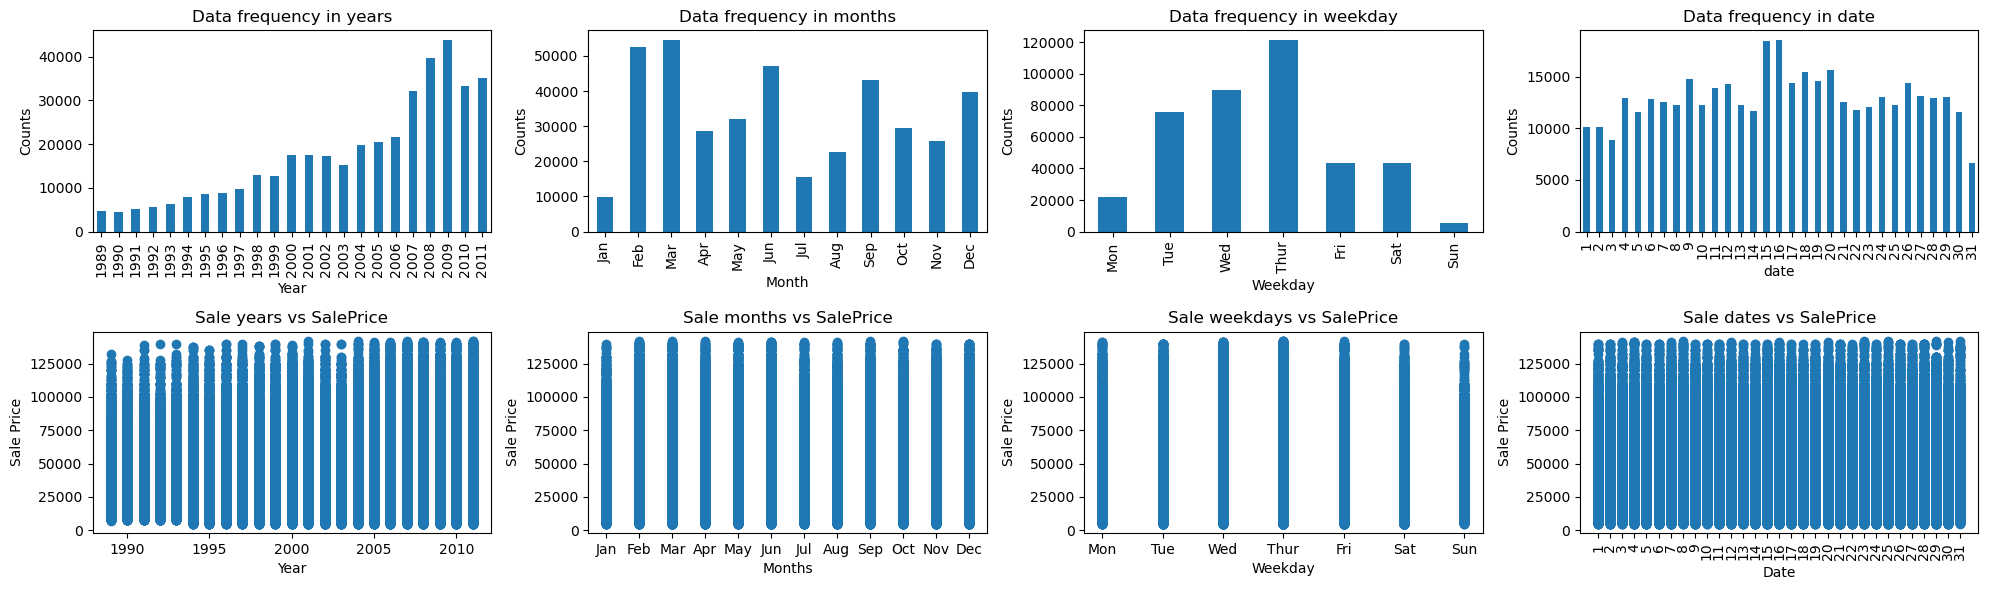

In [21]:
saledate_year = pd.to_datetime(train_df['saledate']).dt.year
saledate_month = pd.to_datetime(train_df['saledate']).dt.month
saledate_weekday = pd.to_datetime(train_df['saledate']).dt.dayofweek
saledate_day = pd.to_datetime(train_df['saledate']).dt.day

fig, axes = plt.subplots(figsize = (20, 6), 
                         ncols = 4,
                         nrows = 2)

saledate_year.value_counts().sort_index().plot.bar(ax = axes[0,0])
axes[0,0].set(title = "Data frequency in years",
             xlabel = "Year",
             ylabel = "Counts")


saledate_month.value_counts().sort_index().plot.bar(ax = axes[0,1])
axes[0,1].set(title = "Data frequency in months",
             xlabel = "Month",
             ylabel = "Counts")
axes[0,1].set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

saledate_weekday.value_counts().sort_index().plot.bar(ax = axes[0,2])
axes[0,2].set(title = "Data frequency in weekday",
             xlabel = "Weekday",
             ylabel = "Counts")
axes[0,2].set_xticklabels(["Mon", "Tue", "Wed", "Thur", "Fri", "Sat", "Sun"])


saledate_day.value_counts().sort_index().plot.bar(ax = axes[0,3])
axes[0,3].set(title = "Data frequency in date",
             xlabel = "date",
             ylabel = "Counts")


axes[1, 0].scatter(saledate_year,
          train_df['SalePrice'])

axes[1, 0].set(title = "Sale years vs SalePrice",
              xlabel = "Year",
              ylabel = "Sale Price")

axes[1, 1].scatter(saledate_month,
          train_df['SalePrice'])
axes[1, 1].set(title = "Sale months vs SalePrice",
              xlabel = "Months",
              ylabel = "Sale Price")

axes[1,1].set_xticks(list(range(1, 13)))
axes[1,1].set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])


axes[1, 2].scatter(saledate_weekday,
          train_df['SalePrice']);
axes[1, 2].set(title = "Sale weekdays vs SalePrice",
              xlabel = "Weekday",
              ylabel = "Sale Price")

axes[1,2].set_xticks(list(range(0,7)))
axes[1,2].set_xticklabels(["Mon", "Tue", "Wed", "Thur", "Fri", "Sat", "Sun"])


axes[1, 3].scatter(saledate_day,
          train_df['SalePrice']);
axes[1, 3].set(title = "Sale dates vs SalePrice",
              xlabel = "Date",
              ylabel = "Sale Price")
axes[1,3].set_xticks(list(range(1,32)))
axes[1,3].set_xticklabels(range(1,32), rotation = 90)

fig.tight_layout()

The bar graphs indicate that we have more data as the time goes by since the amount of data increases as the years pass by.
In addition, there are certain months such as Febuary, March, Jun has more data. Perhaps the machine sales more frequent in those months.

On the other hand, the sale price seems is not affected significantly by time.

Proportion of missing values in Productsize : 52.55 %


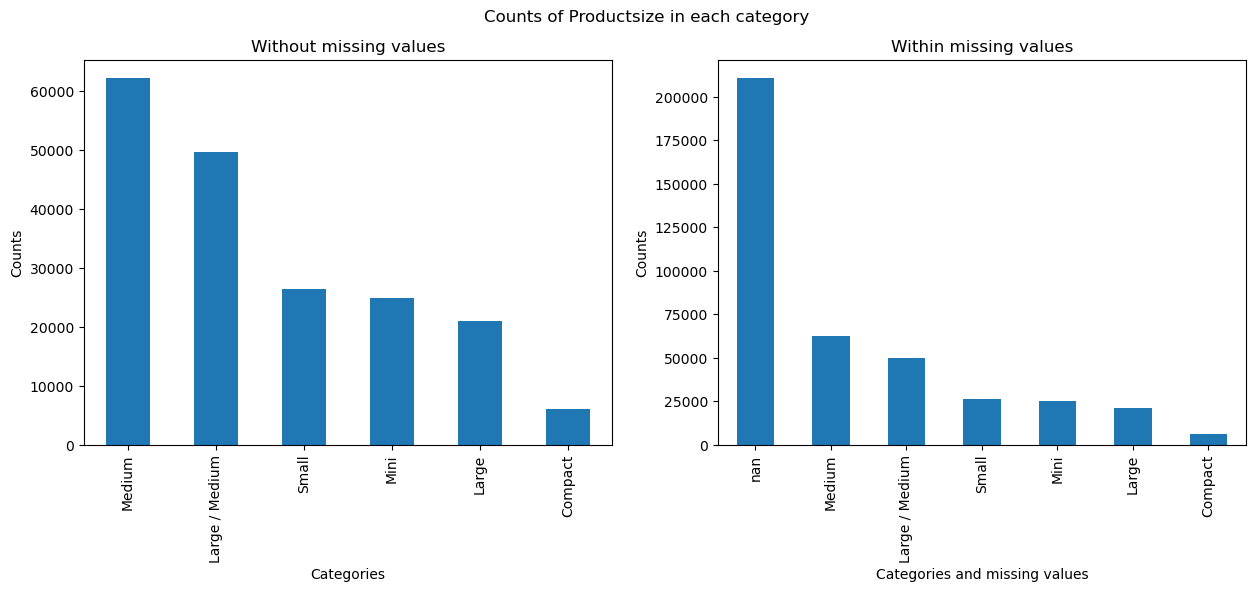

In [22]:
print(f"Proportion of missing values in Productsize : { train_df['ProductSize'].isna().sum() / train_df.shape[0] * 100 :.2f} %")
fig, (ax0, ax1) = plt.subplots(figsize = (15, 5),
                              nrows = 1,
                              ncols = 2)

train_df['ProductSize'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "Without missing values",
       xlabel= "Categories",
       ylabel = "Counts")

train_df['ProductSize'].value_counts(dropna=False).plot.bar(ax = ax1)
ax1.set(title = "Within missing values",
        xlabel = "Categories and missing values",
        ylabel = "Counts")

fig.suptitle("Counts of Productsize in each category");

The following insights are derived from the bar graphs above:

* Missing values in ProductSize account for up to more than half of the training dataset. In other word, we have less than half data in this feature.
* In terms of **Large/Medium** category, it appears to indicate uncertainty as to whether the instance should be classified as Large or Medium
* Medium size appears to have the highest frequency.

In [23]:
train_df['ProductGroup'].unique(), train_df['ProductGroupDesc'].unique()

(<ArrowStringArray>
 ['WL', 'SSL', 'TEX', 'BL', 'TTT', 'MG']
 Length: 6, dtype: str,
 <ArrowStringArray>
 [       'Wheel Loader',  'Skid Steer Loaders',    'Track Excavators',
      'Backhoe Loaders', 'Track Type Tractors',       'Motor Graders']
 Length: 6, dtype: str)

Basically, `ProductGroup` is the abbreviation version of `ProductGroupDesc`, so I will keep `ProductGroup`, and drop `ProductGroup`

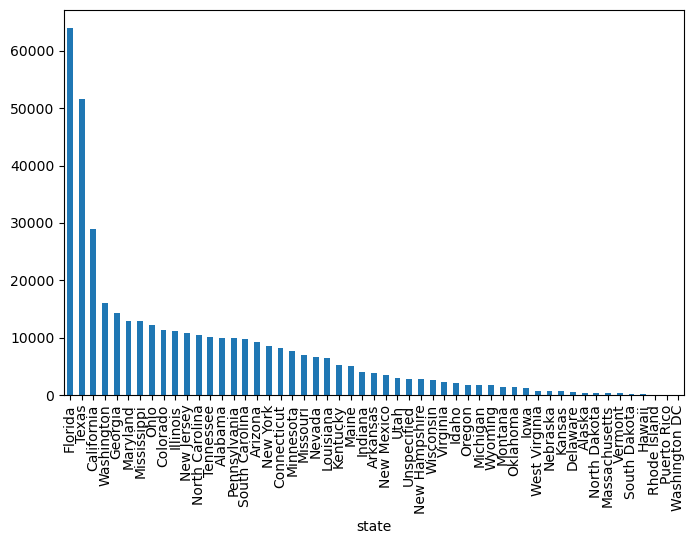

In [24]:
train_df['state'].value_counts().plot.bar(figsize = (8,5));

The demand for Bulldozer in Forida, Texas, California is higher than the other states based on the bargraph above.
Let's check if this related to saleprice.

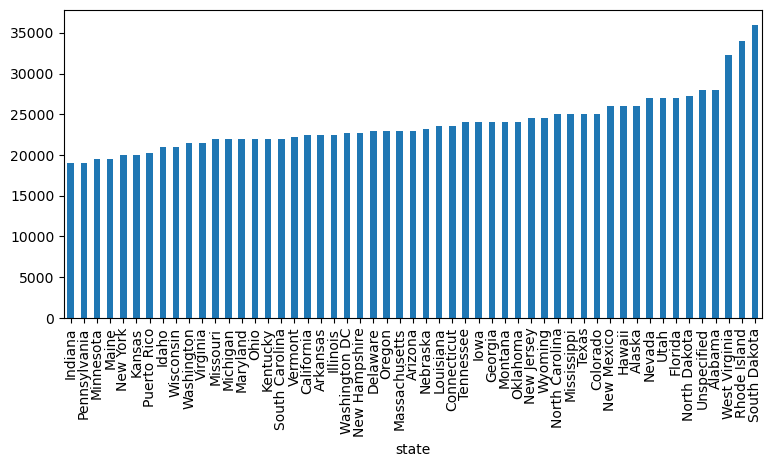

In [25]:
train_df.groupby(['state'])['SalePrice'].median().sort_values().plot.bar(figsize = (9, 4));

Interestingly, the sale price remains unaffected despite the high demand in those states.

There are 73.98% missing data in Drive System
Not sure what does "No" mean. I think I will keep it, and convert this feature to category


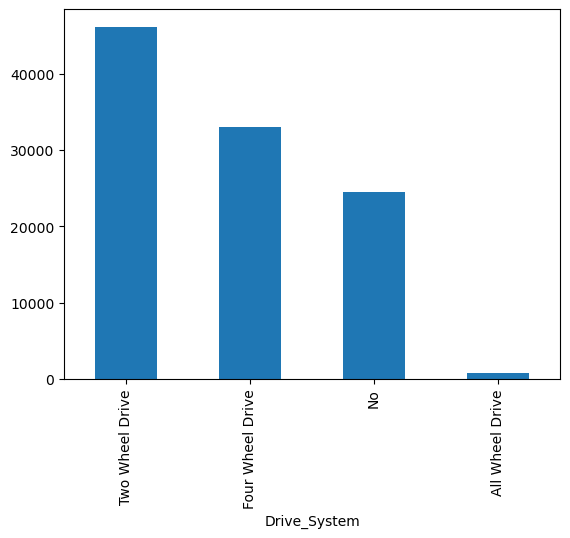

In [26]:
print(f"There are {train_df['Drive_System'].isna().sum() / train_df['Drive_System'].shape[0] * 100:.2f}% missing data in Drive System")
train_df['Drive_System'].value_counts().sort_values(ascending = False).plot.bar();

print("Not sure what does \"No\" mean. I think I will keep it, and convert this feature to category")

There are plenty of features to explore, and that is quite tedious, so I am applying the function written as below to check the rest of features.

In [27]:
def categorical_features_plot(feature_name):
    
    # print(f"{feature_name} has {train_df[feature_name].isna().sum() / train_df.shape[0] * 100:.2f}% of missing data")        
    fig, (ax0, ax1, ax2) = plt.subplots(figsize = (18, 4),
                      nrows = 1,
                      ncols = 3)

    train_df[feature_name].value_counts().sort_values().plot.bar(ax = ax0)
    ax0.set(title = "Data counts in each category",
           xlabel = f"Categories of {feature_name}",
           ylabel = "Frequency")
    
    
    train_df.groupby([feature_name])['SalePrice'].mean().sort_values().plot.bar(ax = ax1)
    ax1.set(title = f"Mean of sale price by {feature_name}",
           xlabel = "Categories of Ripper",
           ylabel = "Price")

    train_df.groupby([feature_name])['SalePrice'].median().sort_values().plot.bar(ax = ax2)
    ax2.set(title = f"Median of sale price by {feature_name}",
           xlabel = "Categories of Ripper",
           ylabel = "Price")
    
    fig.suptitle(f"{feature_name} has {train_df[feature_name].isna().sum() / train_df.shape[0] * 100:.2f}% of missing data",
                color = "red")
    fig.tight_layout;

/var/folders/mf/3wt3q1y17_3fr_j24qtf31bm0000gn/T/ipykernel_48569/4287680389.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax0, ax1, ax2) = plt.subplots(figsize = (18, 4),


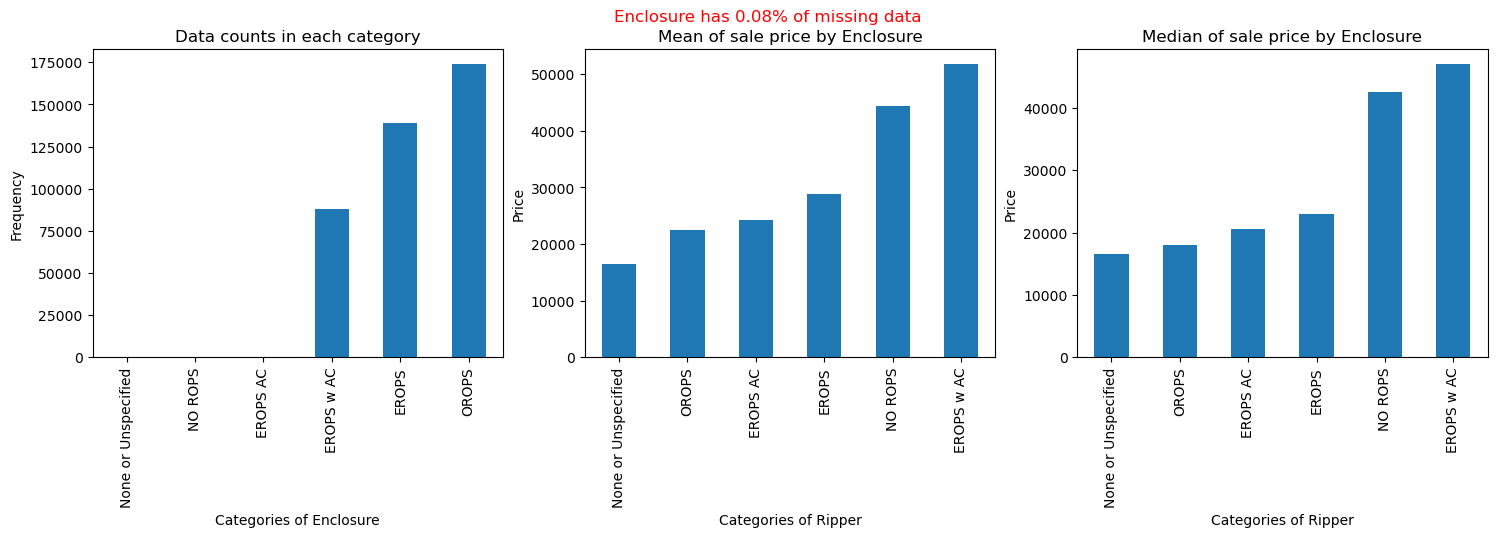

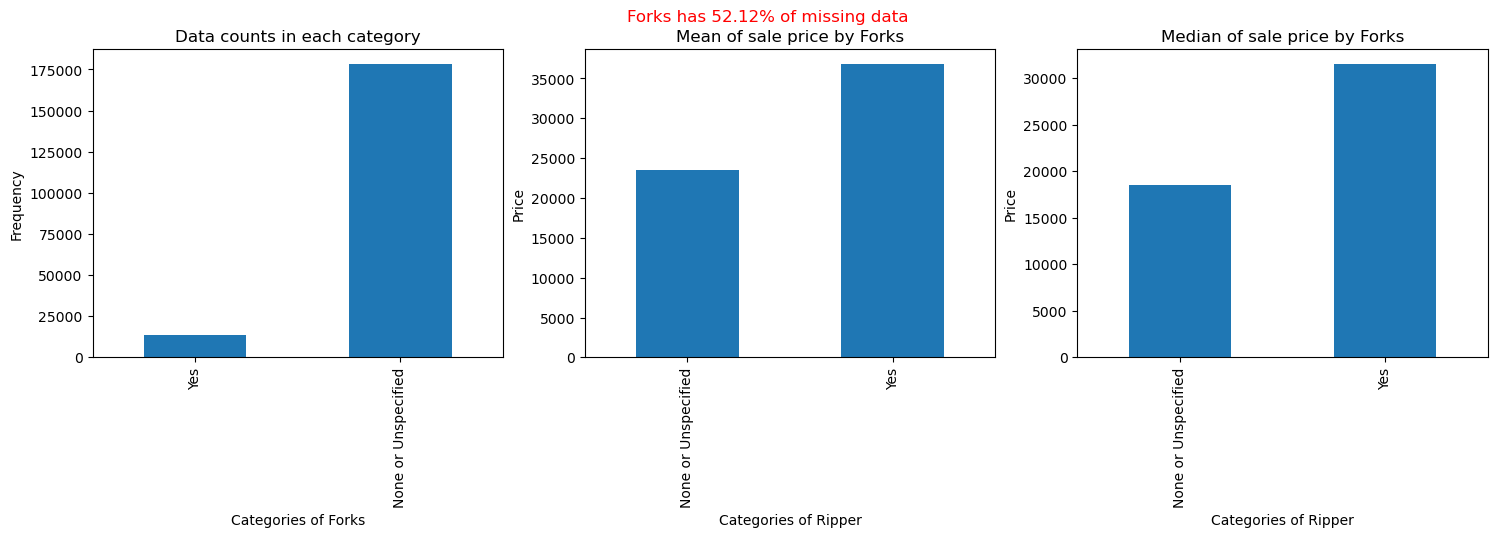

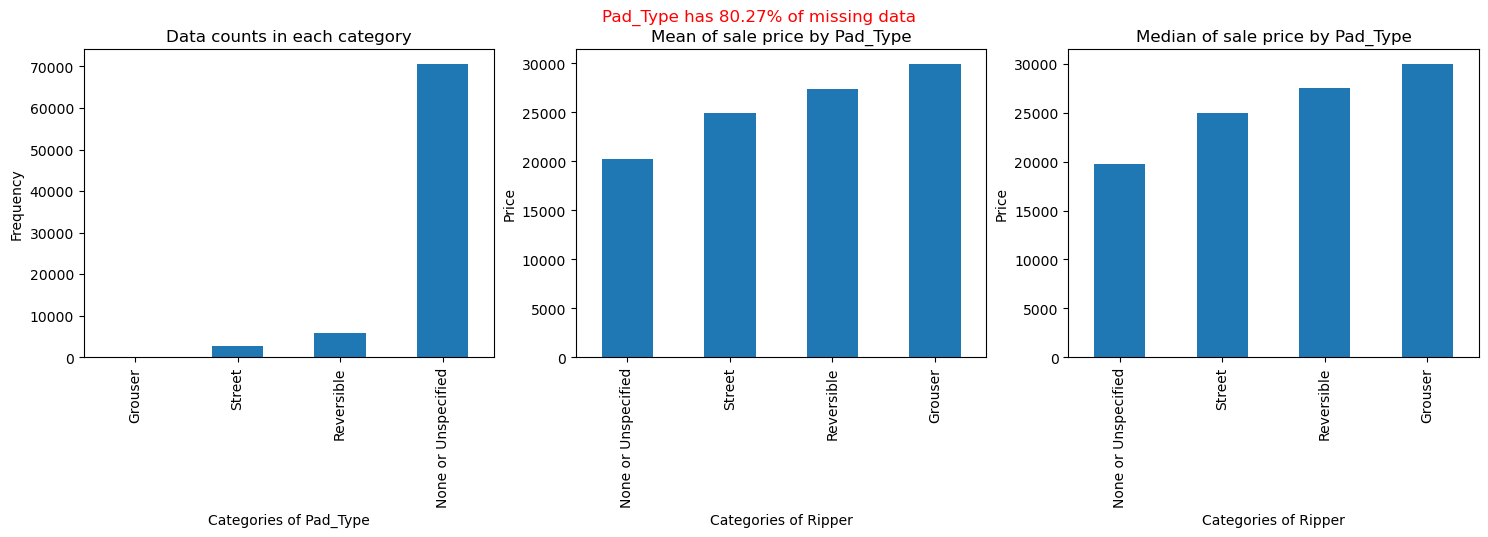

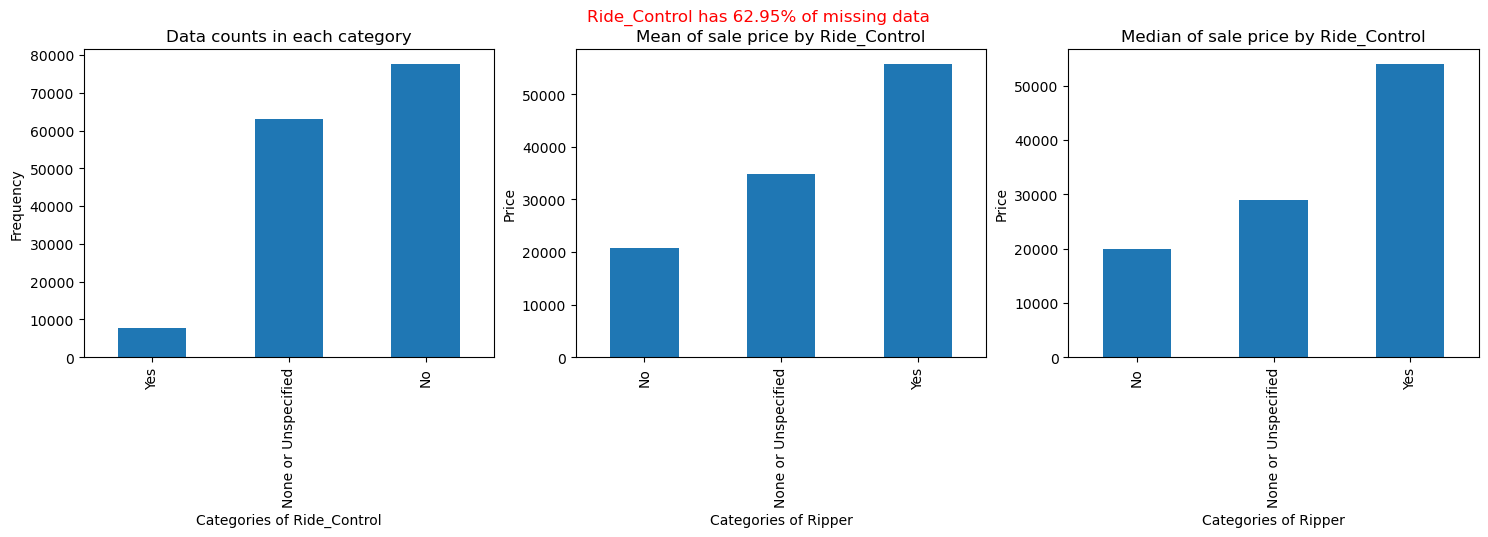

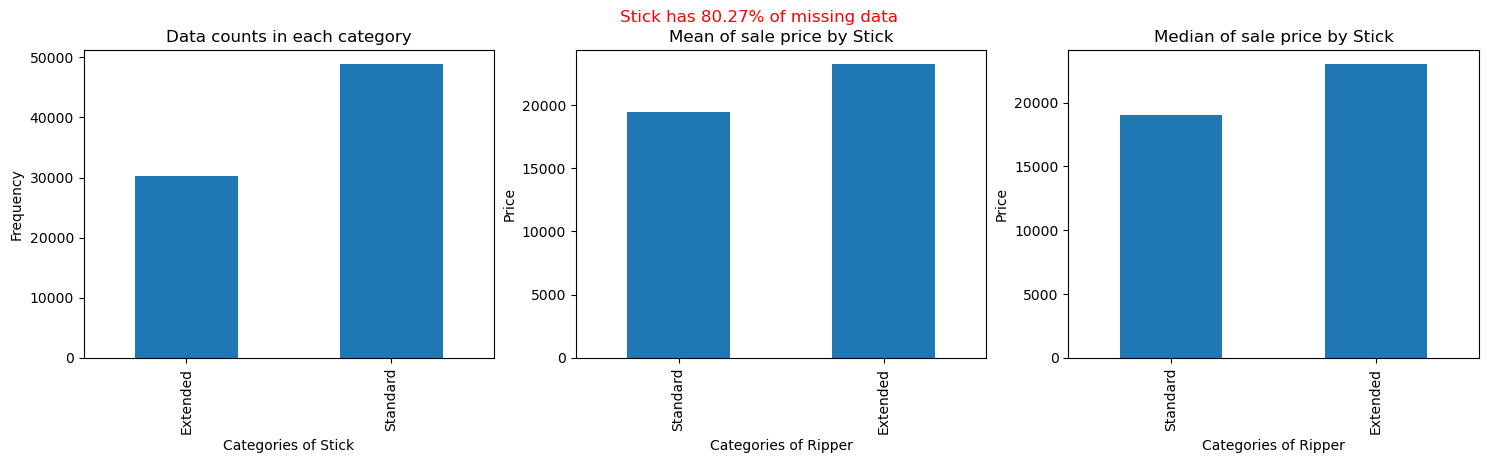

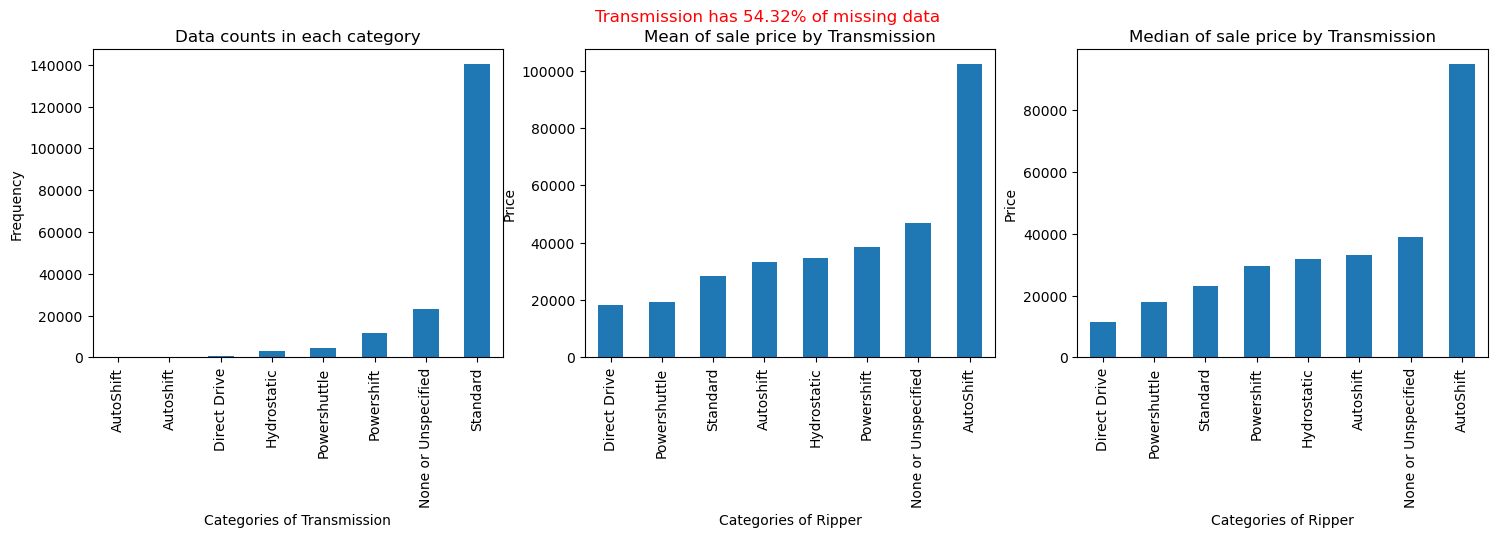

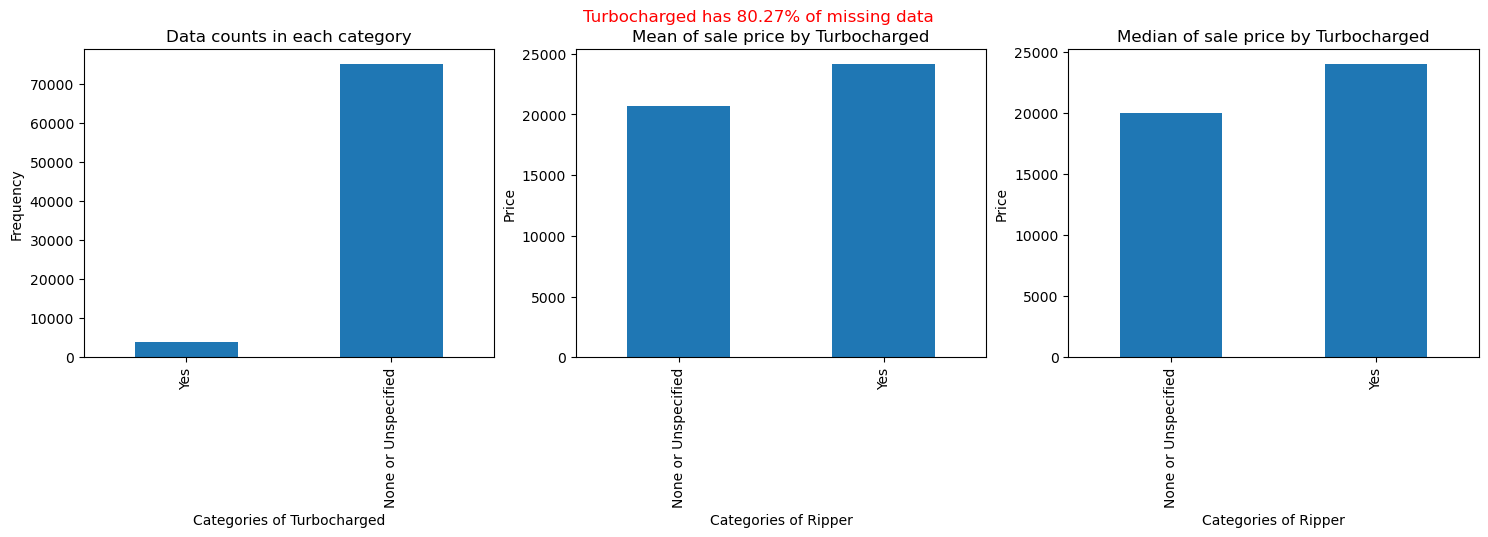

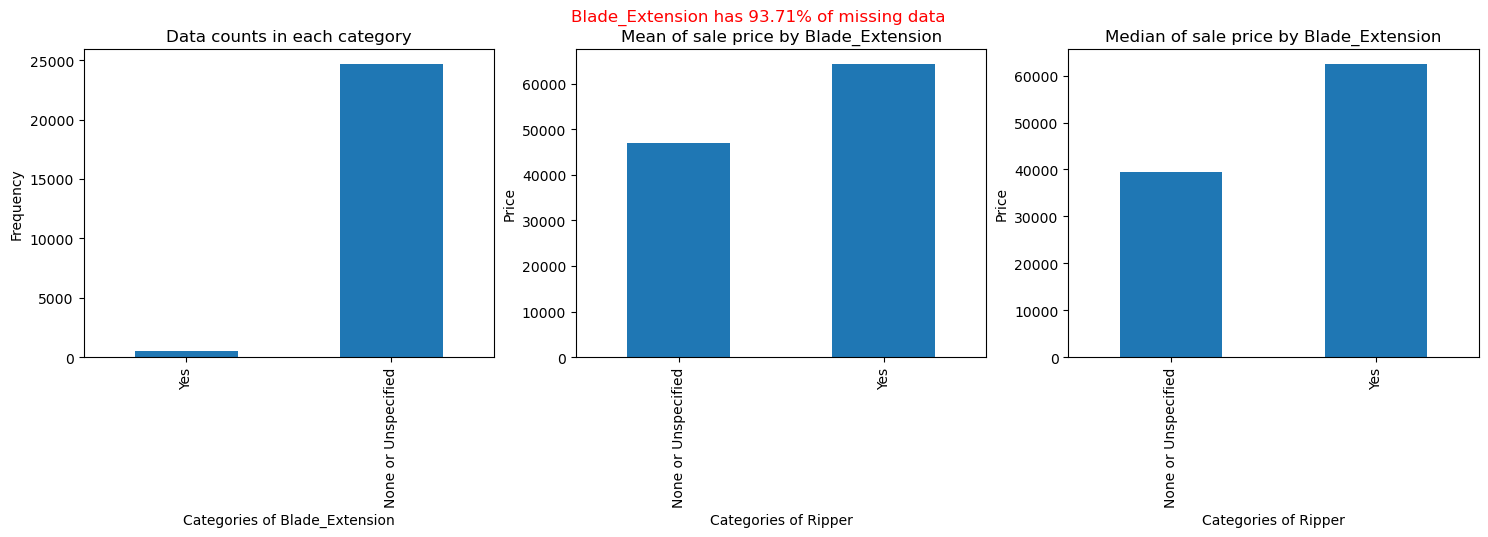

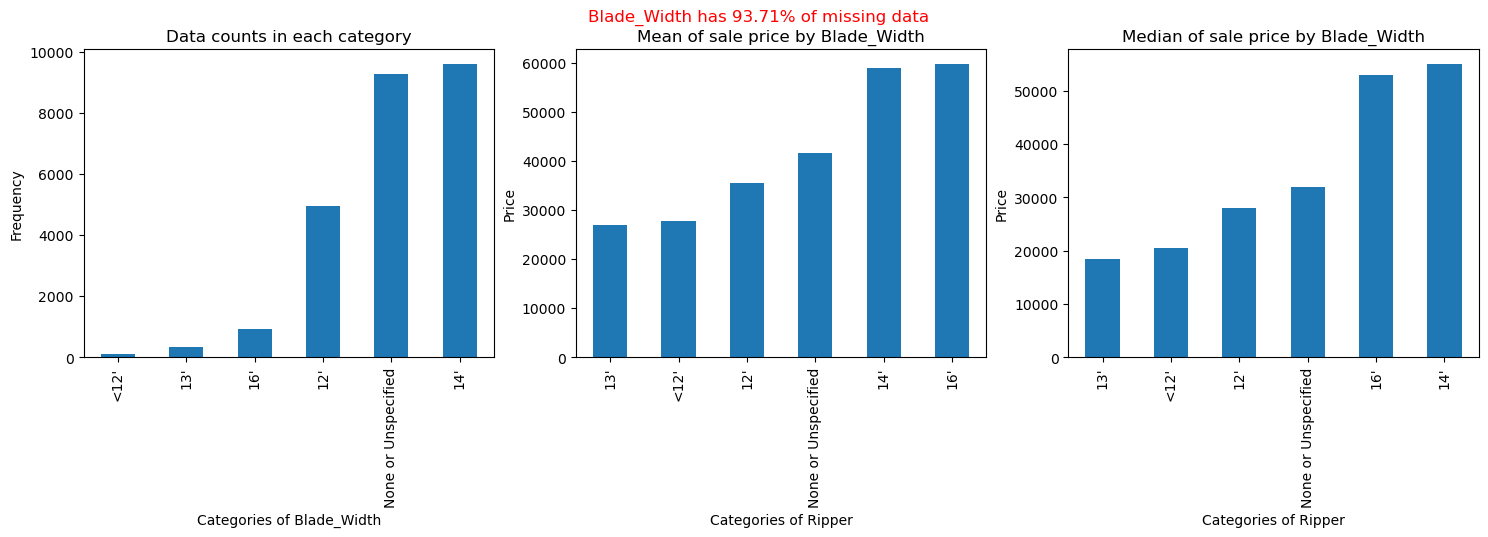

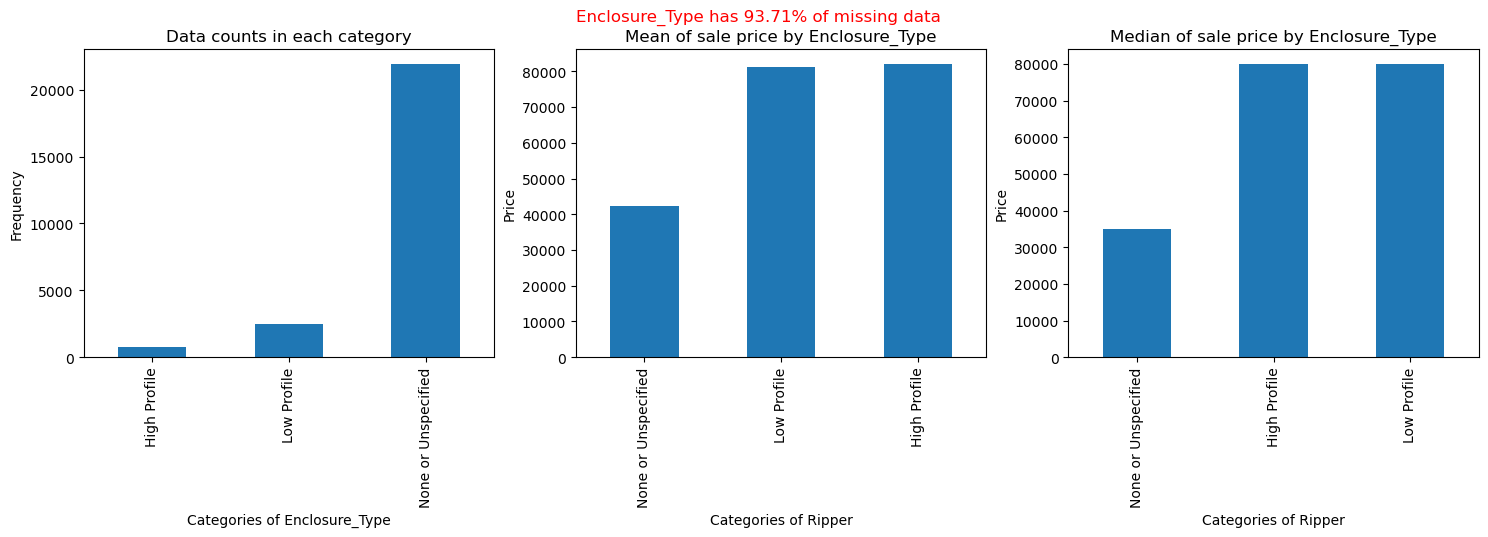

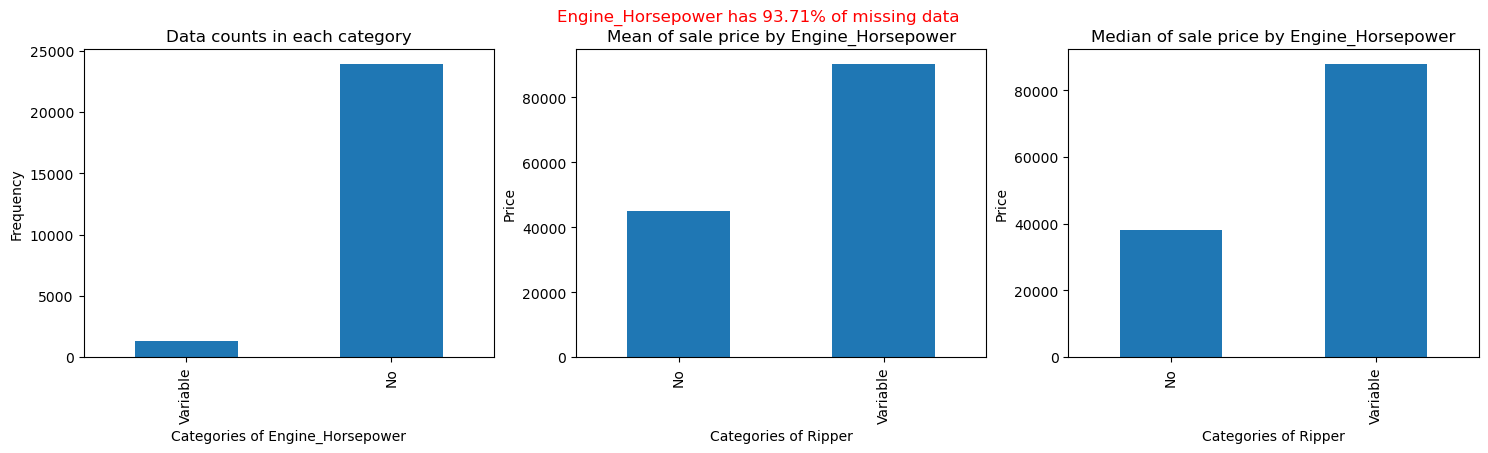

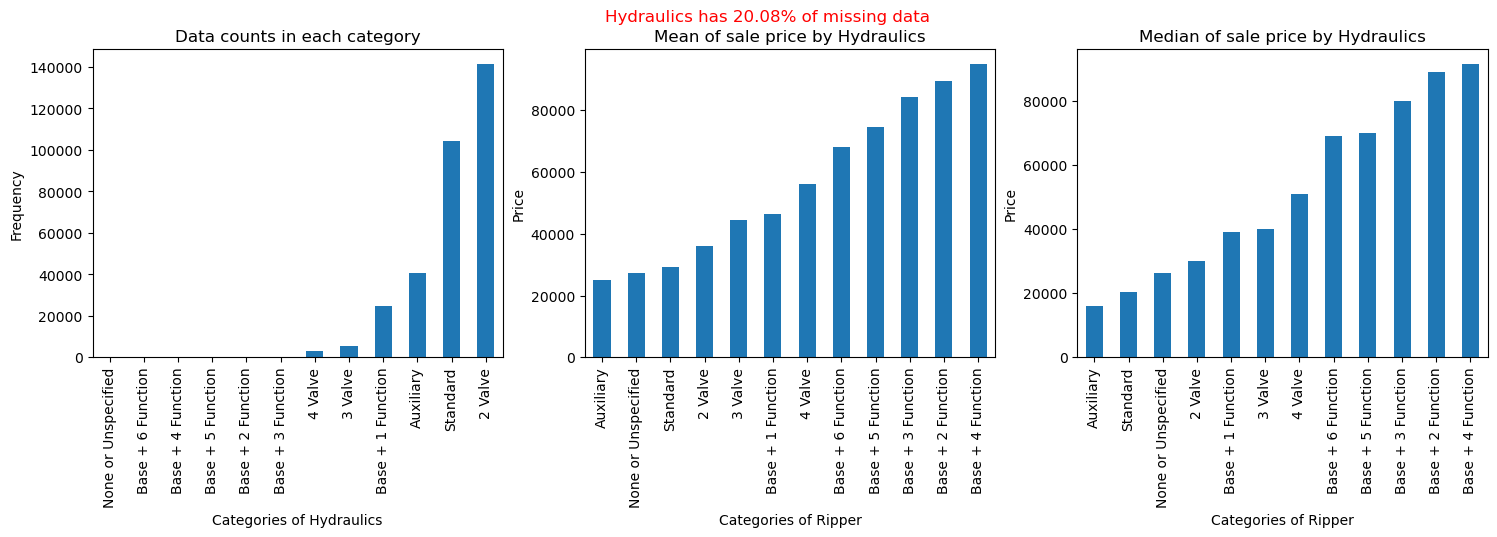

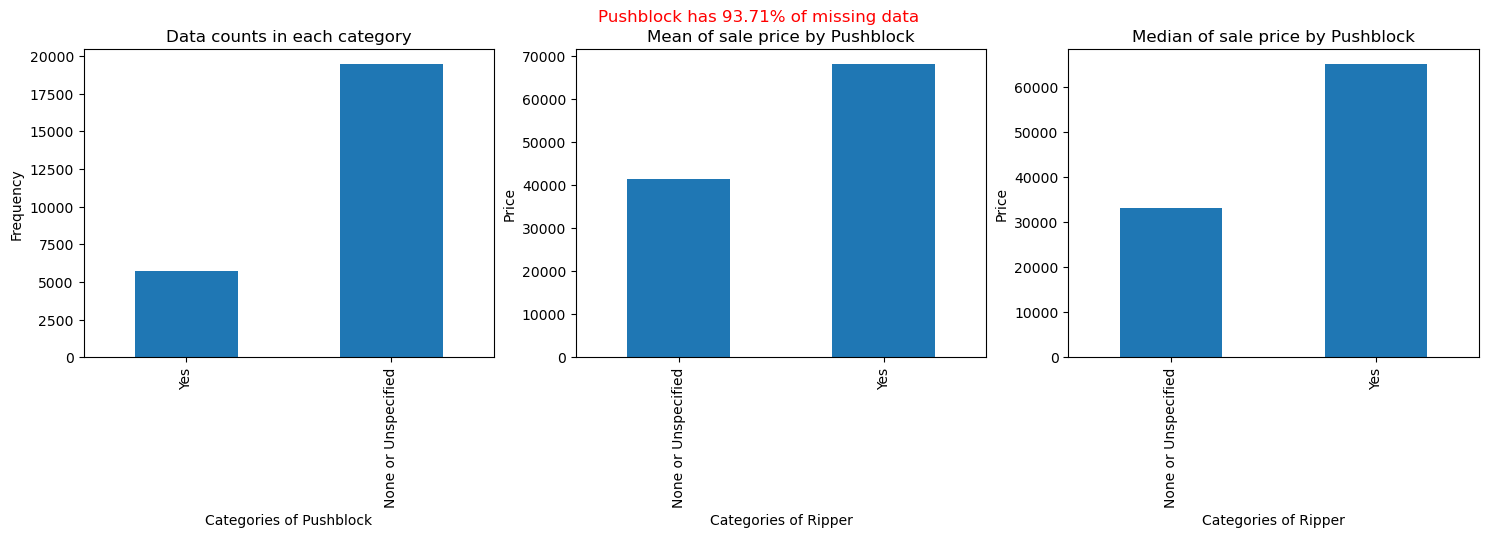

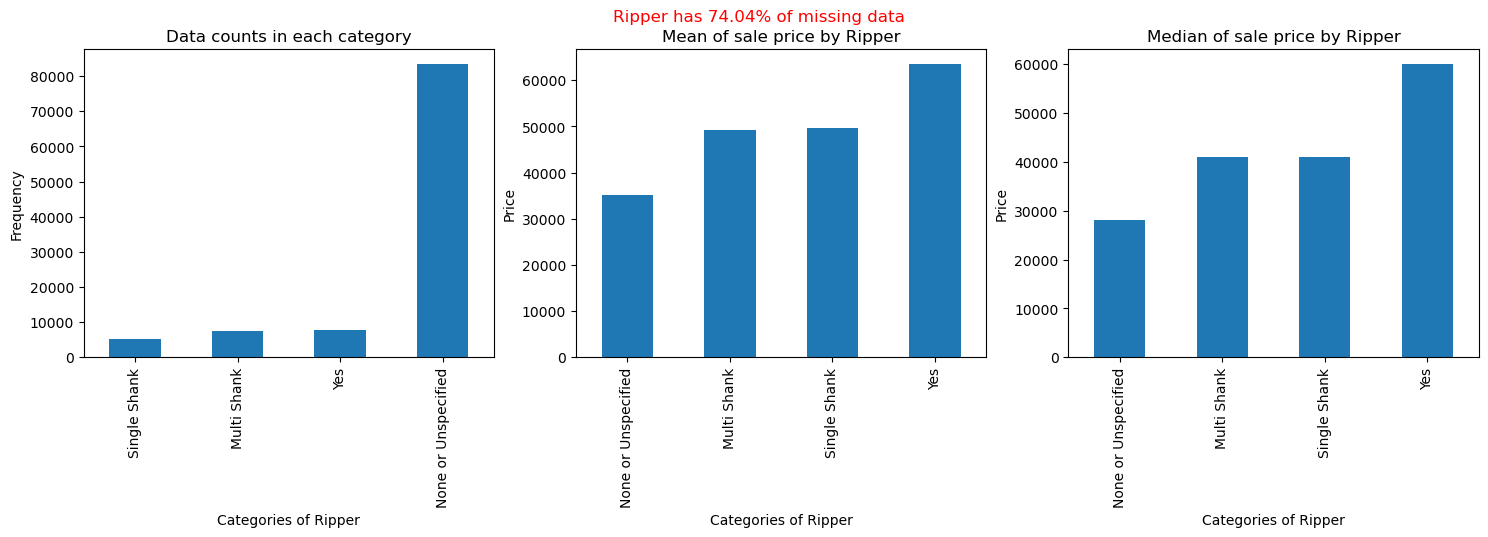

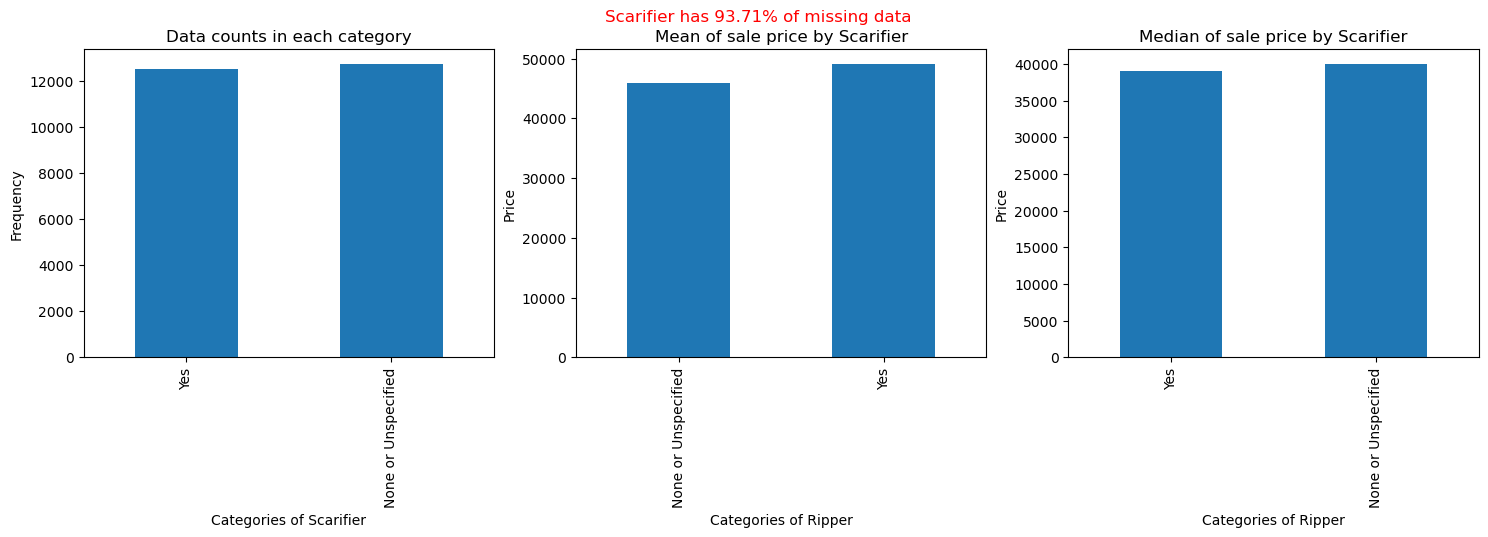

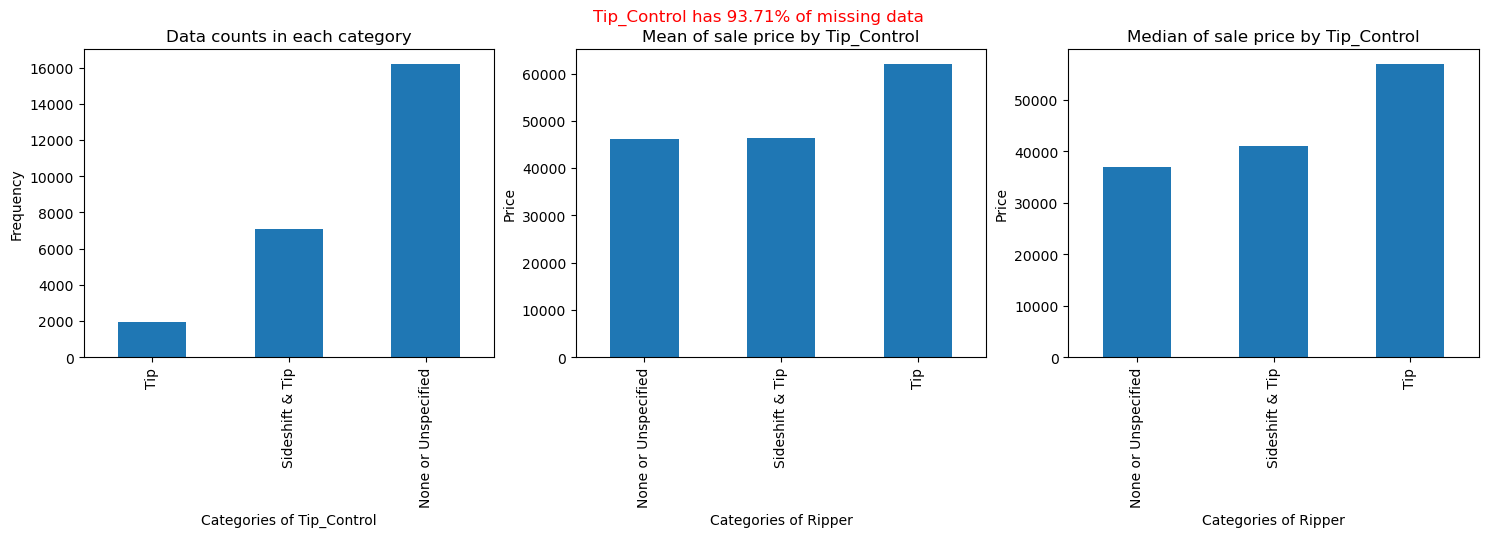

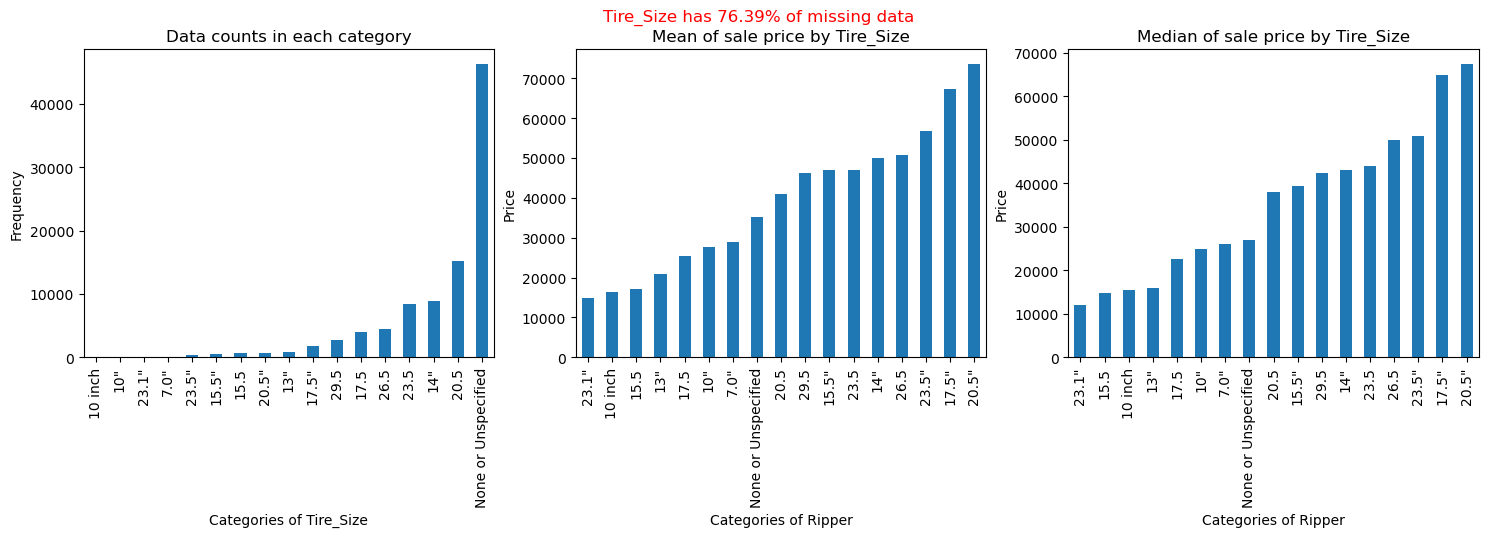

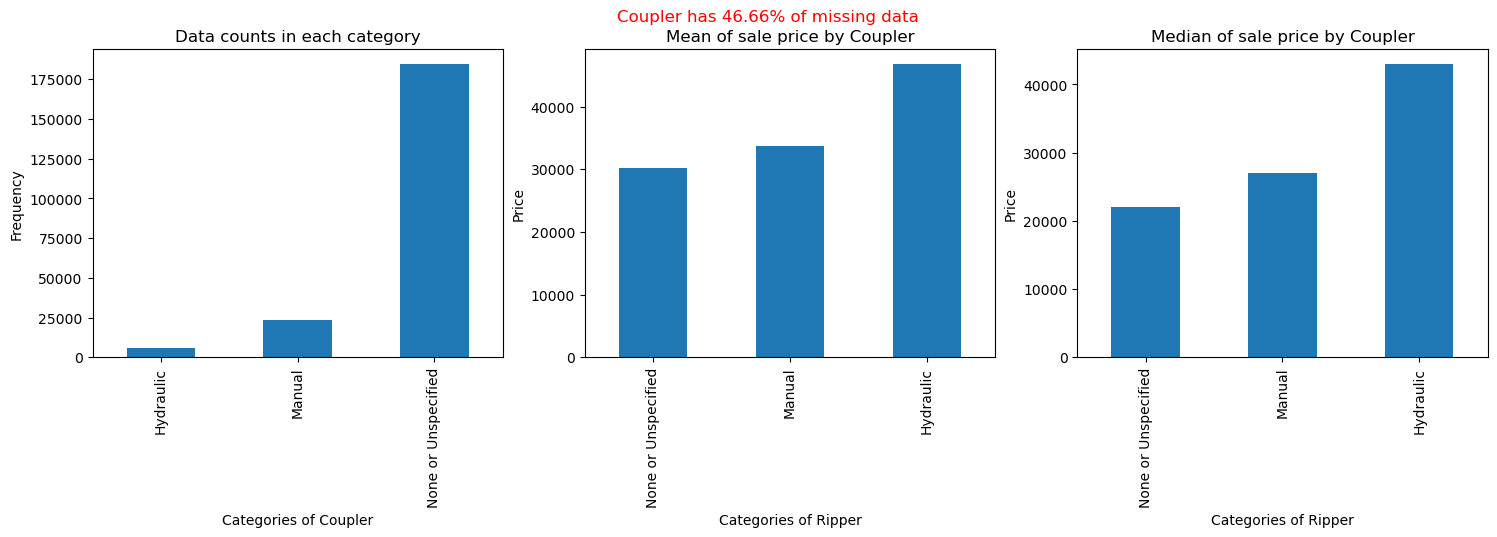

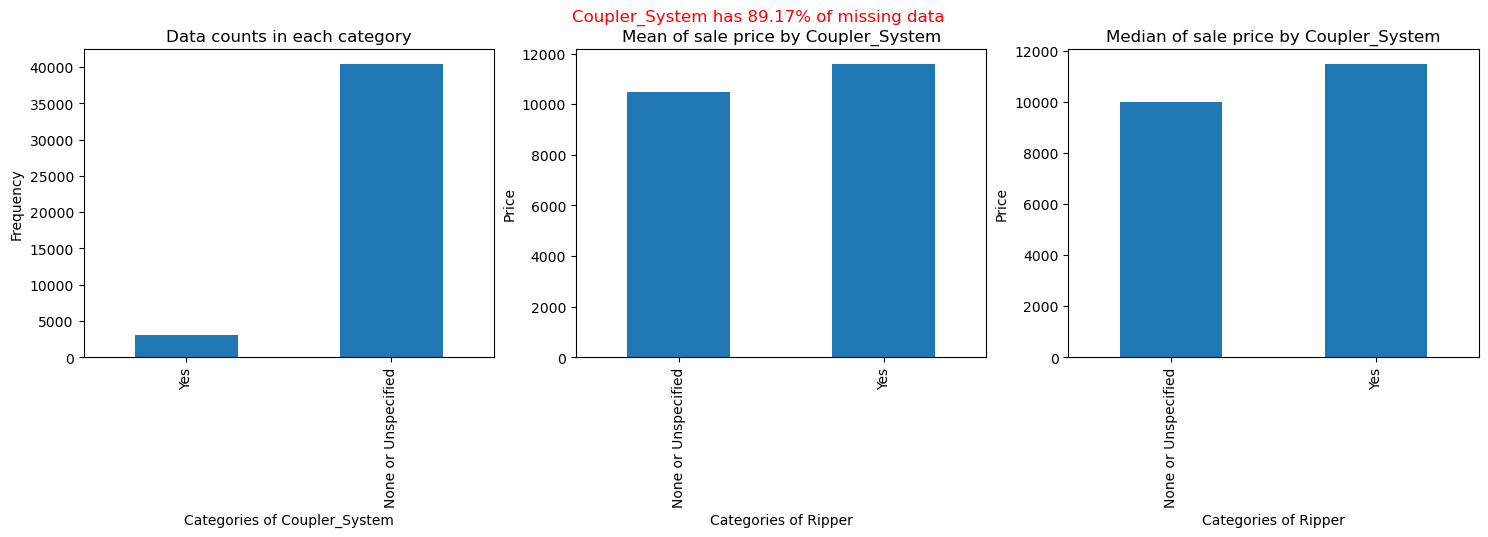

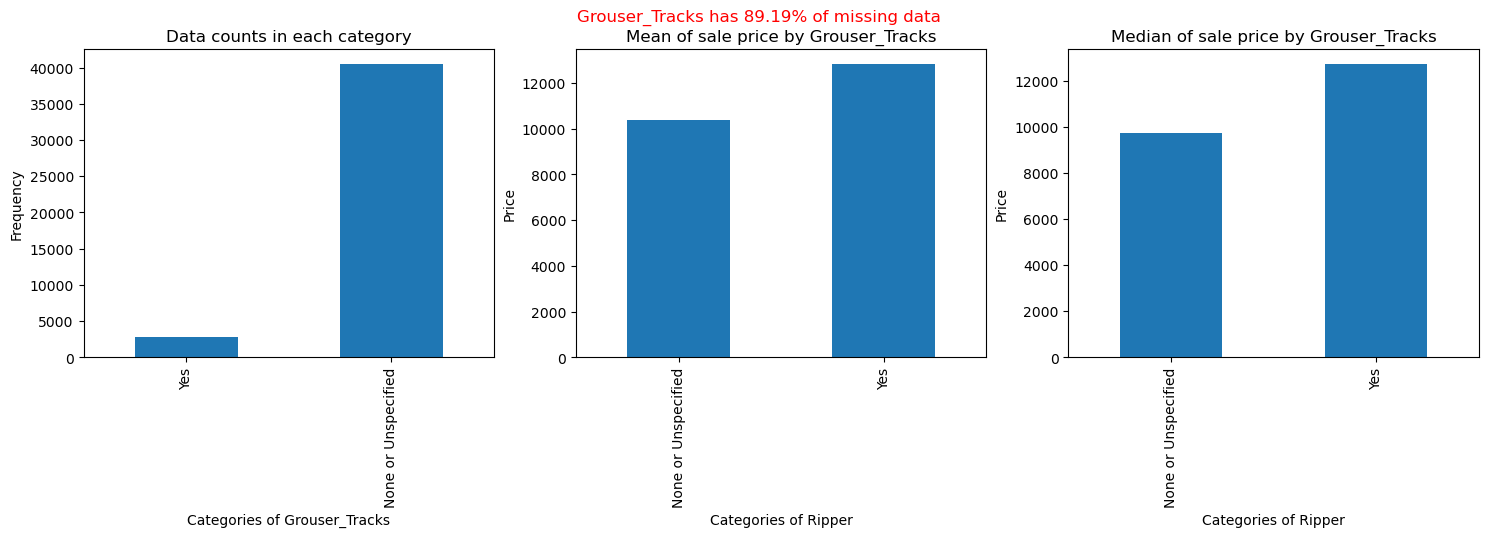

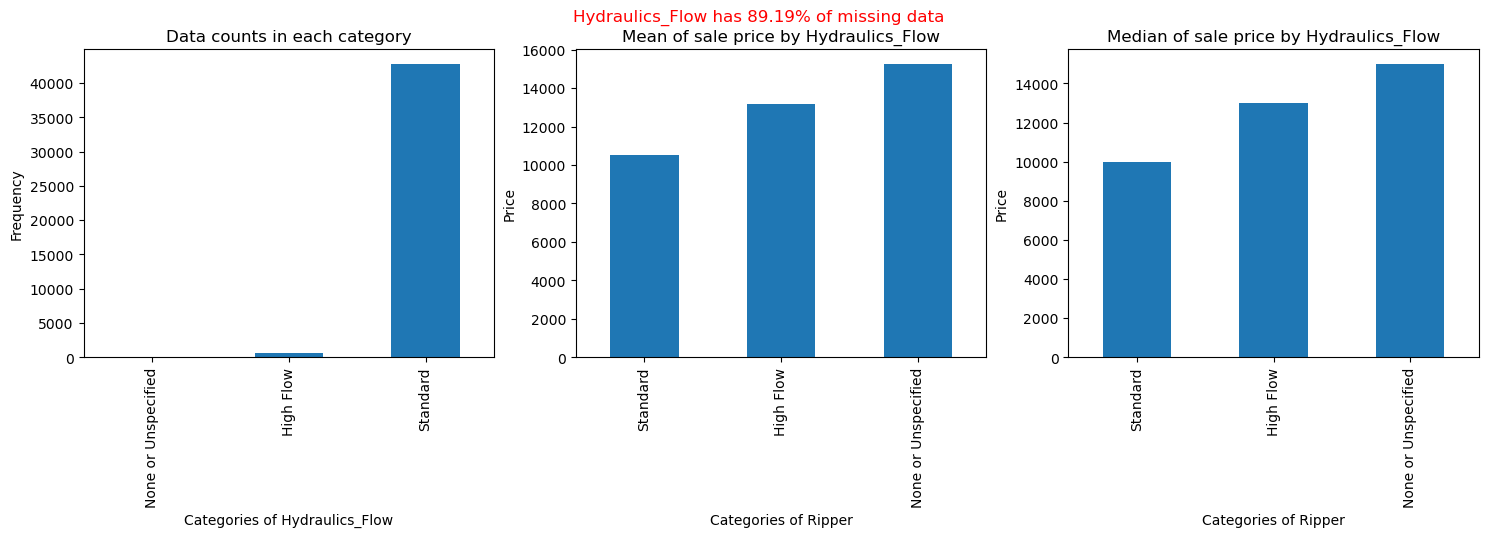

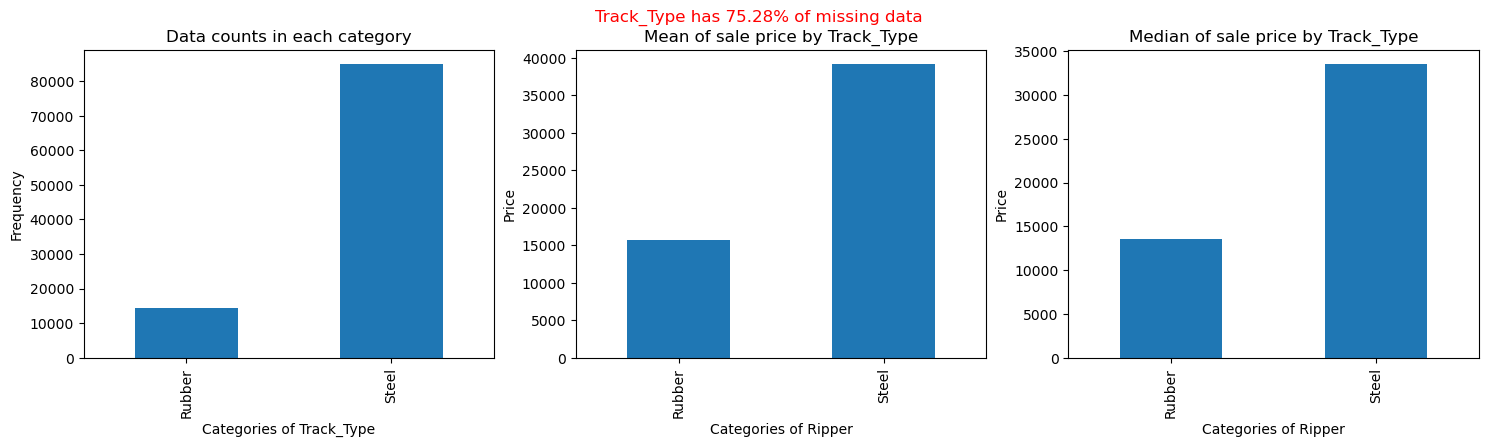

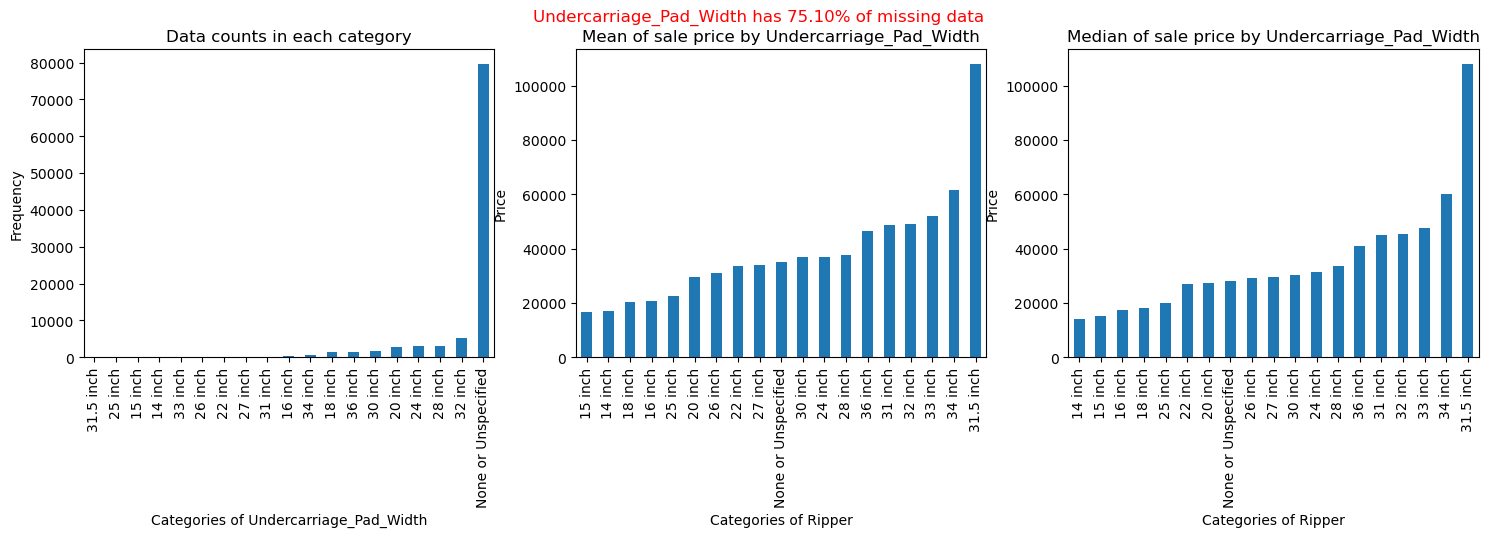

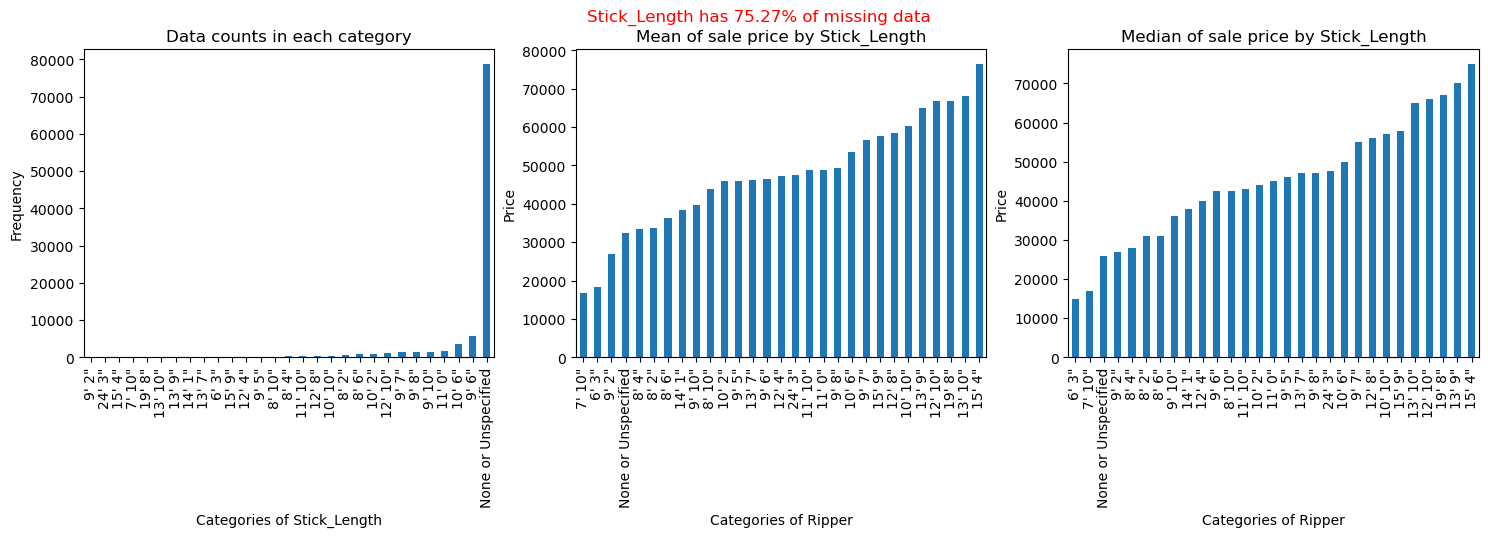

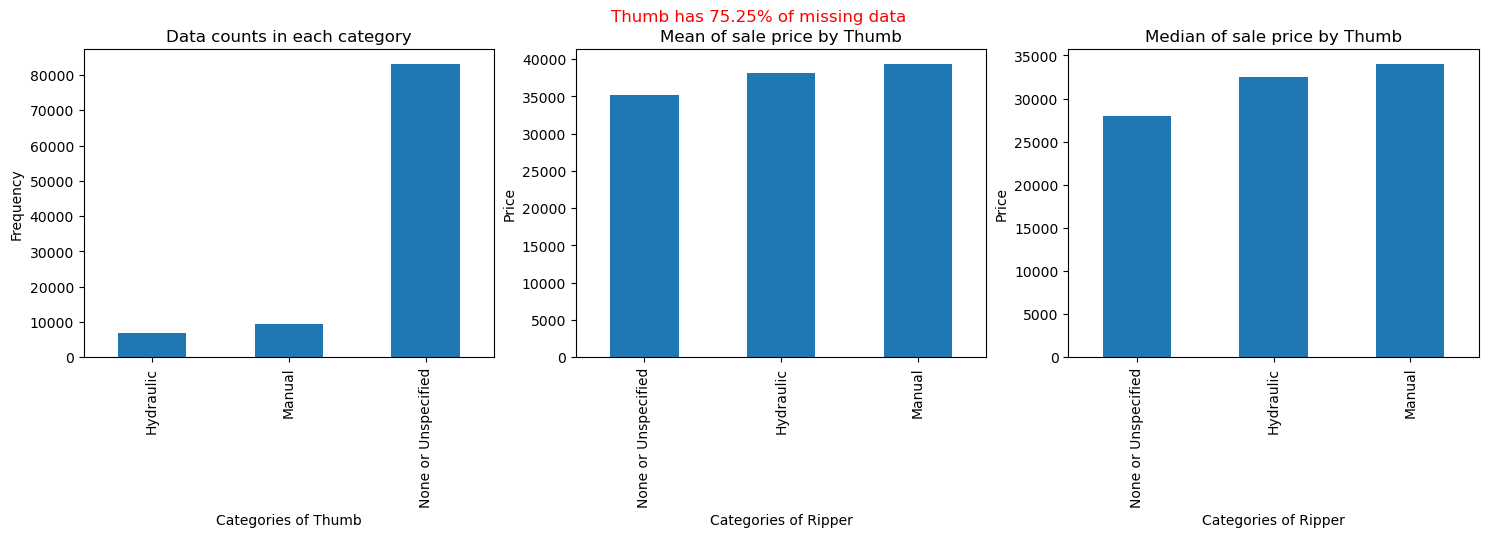

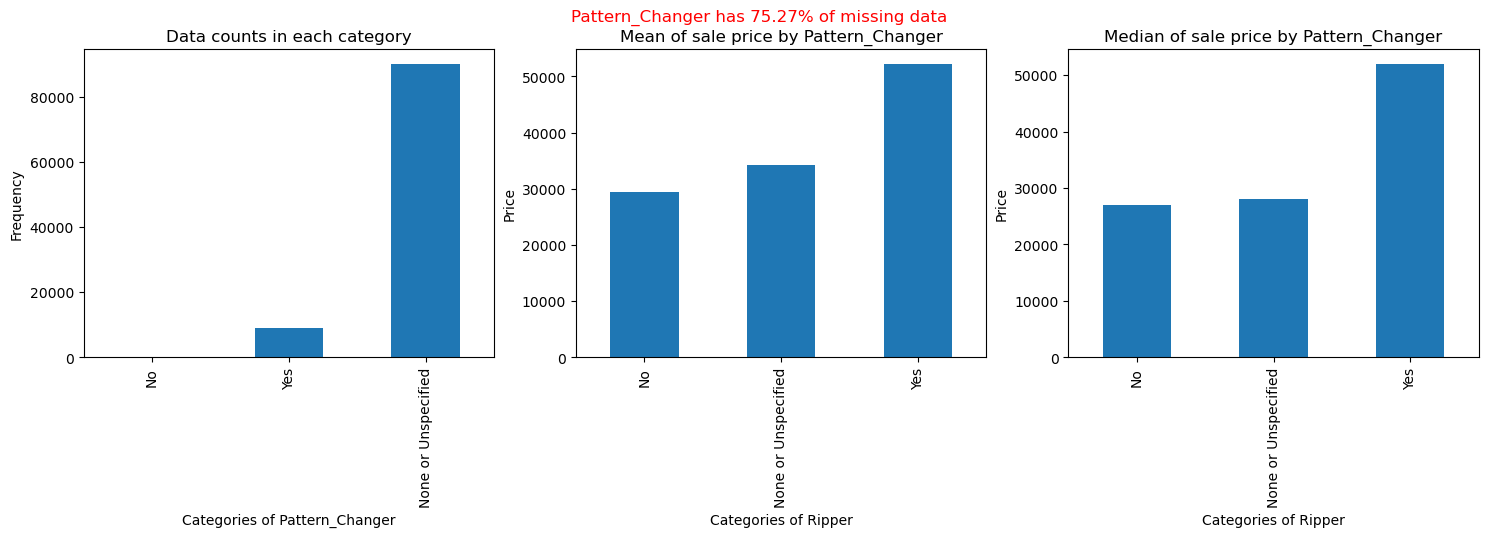

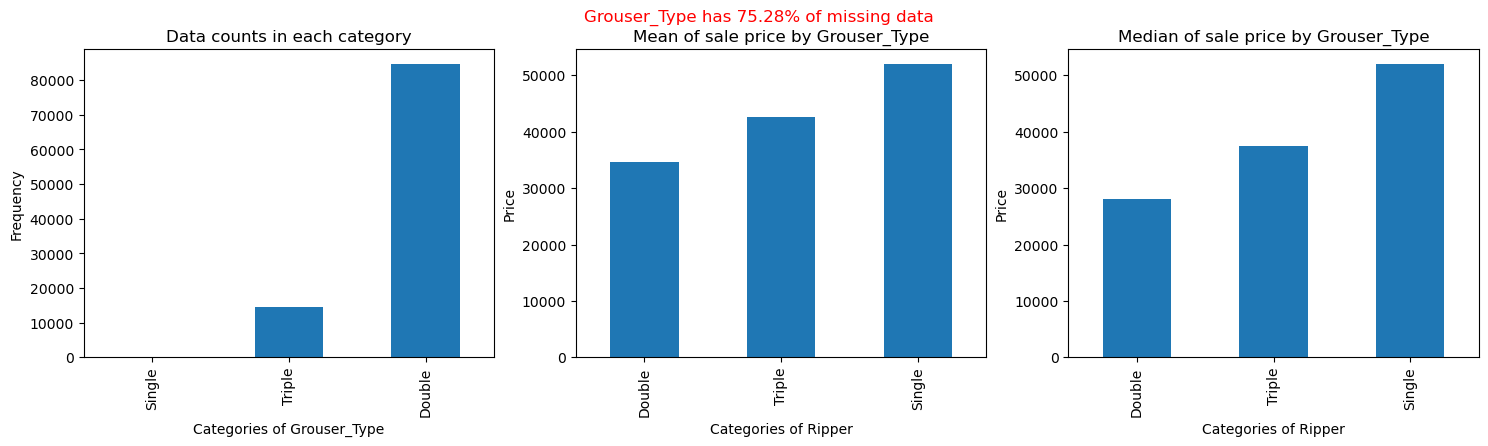

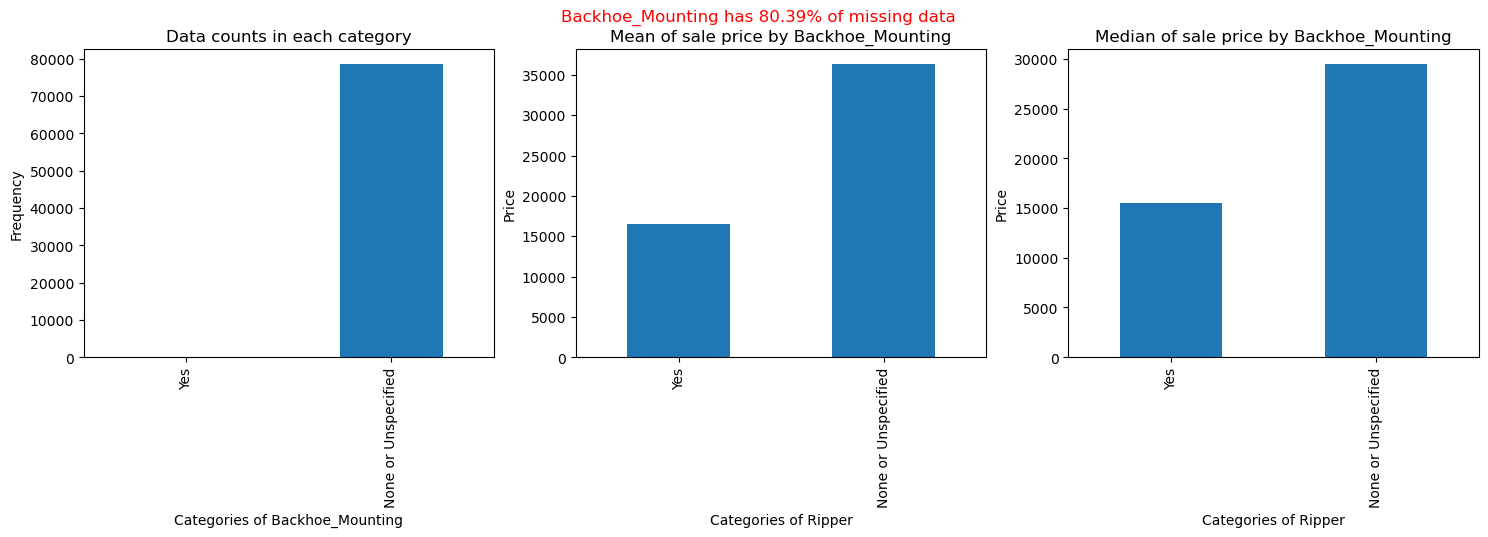

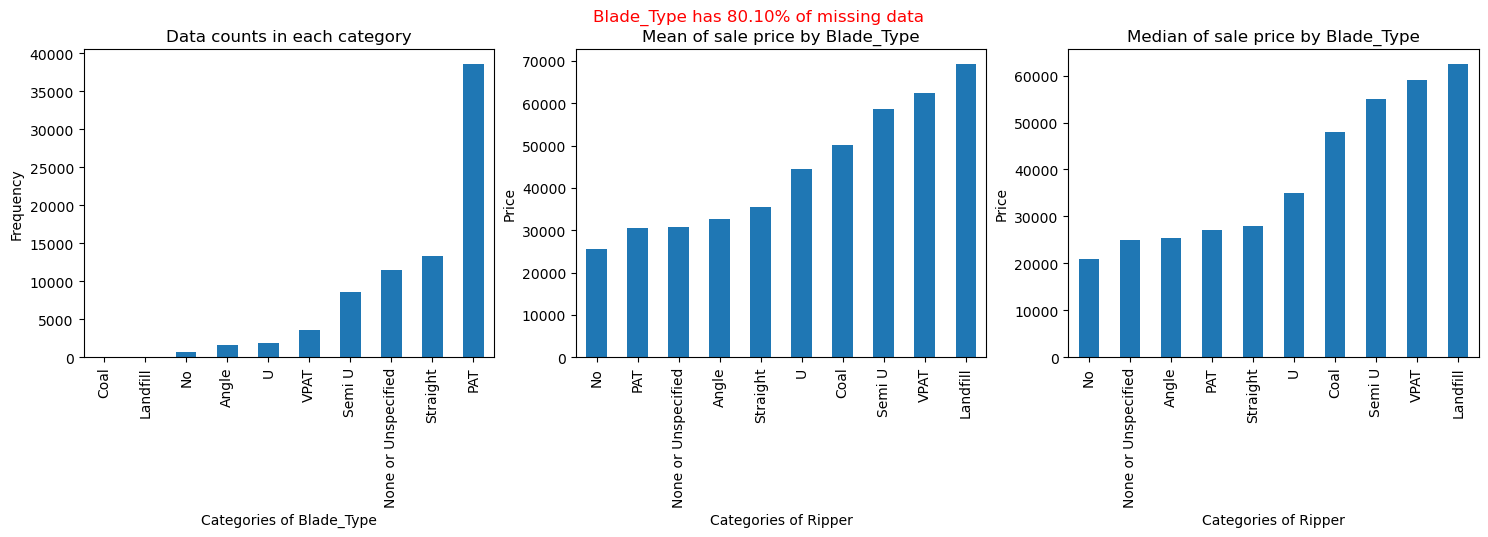

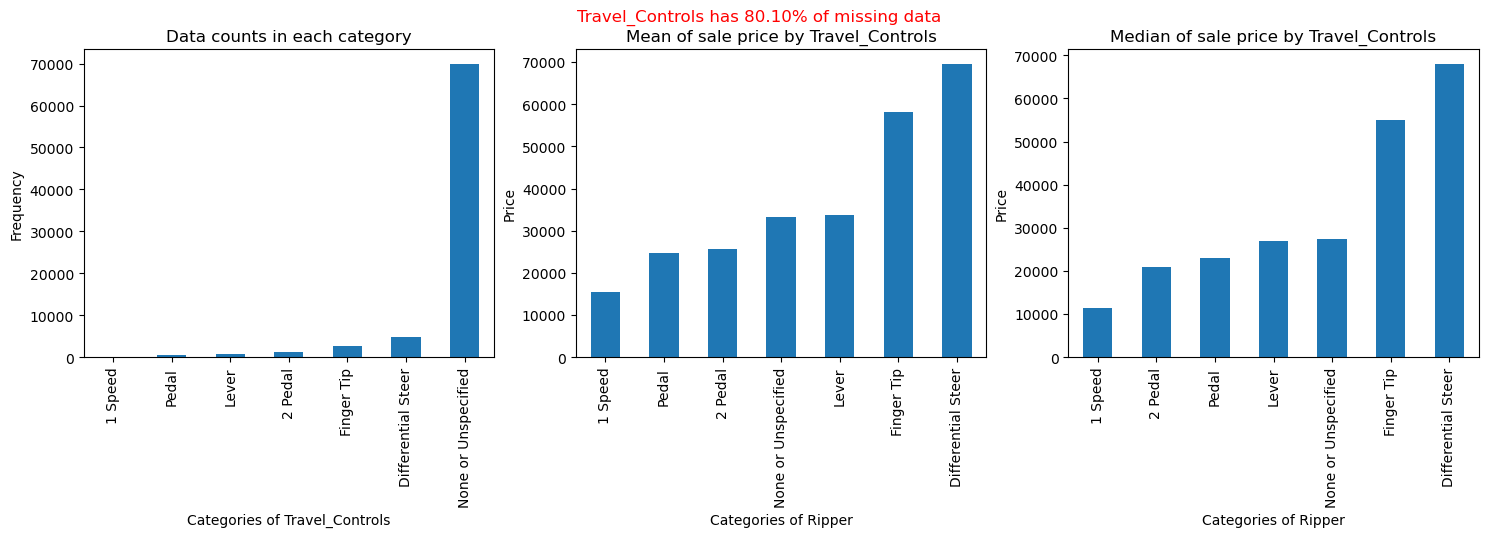

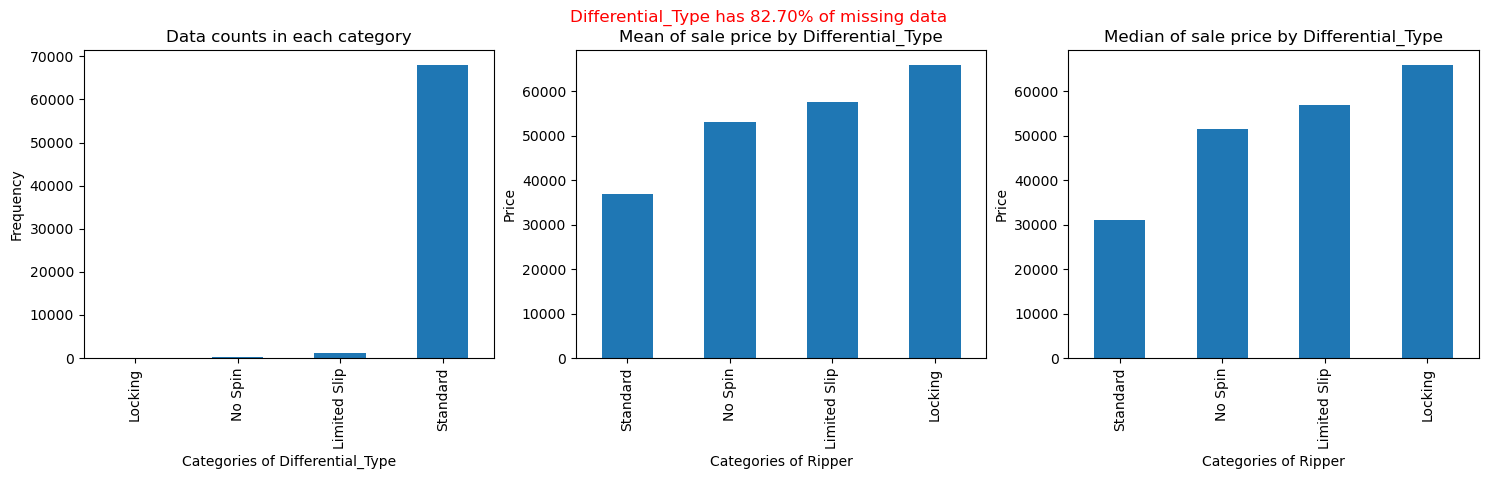

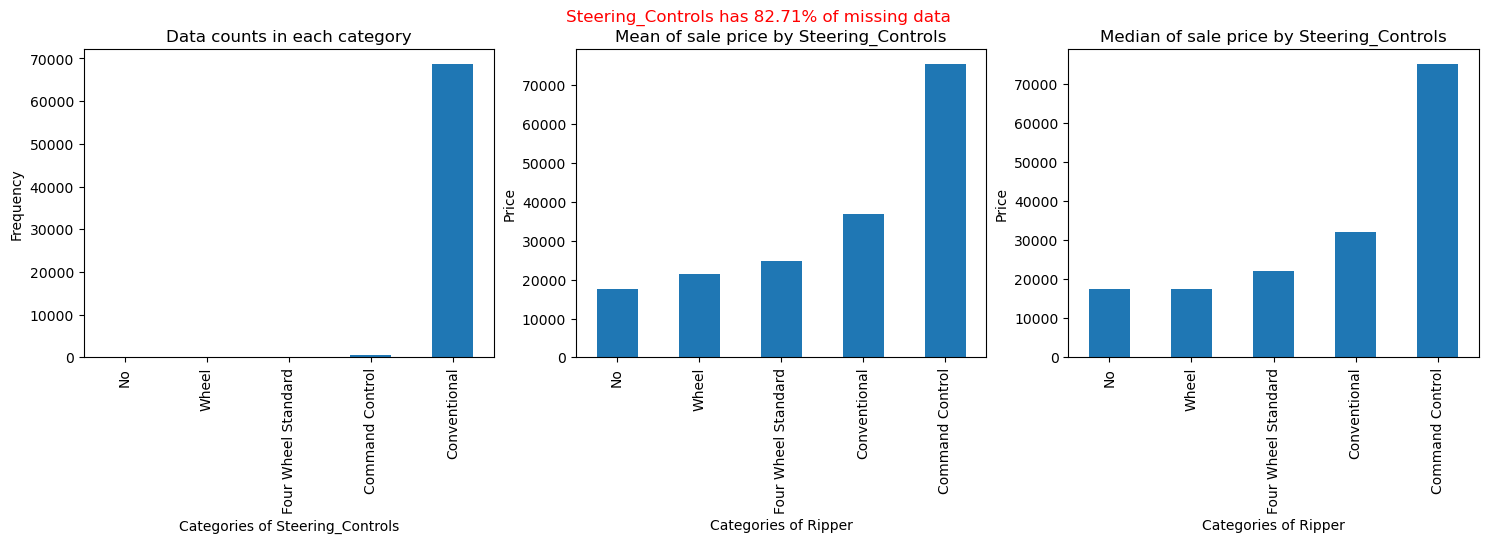

In [28]:
for col in ['Enclosure', 'Forks', 'Pad_Type', 'Ride_Control','Stick', 'Transmission', 'Turbocharged', 'Blade_Extension','Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size','Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow','Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type','Travel_Controls', 'Differential_Type', 'Steering_Controls']:
    categorical_features_plot(col)
    plt.show;

The category "None" of some features are mixed with missing values, and the data is seriously unbalanced, such as `Forks`, `Pad_Type`, `Ride_Control`, `Turbocharged`, `Blade_Extension`, and more.

#### Enclosure & Enclosure_Type
Enclosure describes whether machine has an enclosed cab or not
"Enclosure" is clearly related to "Enclosure_type". Therefore, I will drop "Enclosure_type", and then convert "Enclosure" to categorical data type

#### Forks
I wanted to drop this feature initially, but the graph indicates that the sale price increases when the machine has Forks. Therefore, I will keep this feature, and conver it from str to category

#### Transmission
It specifies types of transmission that could be cassified as automatic and manual briefly.
Notably, that Autoshift has the highest sale price despites it accounts the least proportion of machine.
Additionally, there are 2 Autoshift, I think they should be merged

#### Hydraulics
`Base + 4 Function`,  `Base + 2 Function`, and `Base + 3 Function` are the top 3 highest price in respective order whereas these 2 categories accounts for the least proportion of data.

#### Coupler and Coupler_System
`Coupler_System` is likely to associated with `Coupler`. Also, the bar graph indicates that `Coupler_System` does not influence sale price, so I decided to drop this feature. 

## Data Pre-processing

1. **Split data into features and target**
2. ✅ **Dealing with datetime features**
    * Since this is a time series data, I would like to sort DataFrame by `saledate`.
    * convert the datatype of `saledate` to **datetime**.
    * Enrich datatime features by creating `saleYear`, `saleMonth`, `saleDay`, `saleWeekday`, `saleDayOfYear`
3. ✅ **Drop features:** `fiModelDesc`, `fiBaseModel`, `fiSecondaryDesc`, `fiModelSeries`, `fiModelDescriptor`, `ProductGroupDesc`, `Enclosure_type`, `Coupler_System`
4. ✅ **merge `train_df[train_df['Transmission'] == 'Autoshift']` and `train_df[train_df['Transmission'] == 'AutoShift']`**
5. ✅ `YearMade`: Replacing the year 1000 to `na value` or the year by inferring it from other entries with the same ModelID   
6. **Transforming Data type**
    * ✅ Ordinal Category: `Blade_Width`, `Tire_Size`, `Undercarriage_Pad_Width`, `Stick_Length`, `Grouser_Type`, `ProductSize`, `UsageBand`
    * ✅ Binary category: `Forks`, `Turbocharged`, `Blade_Extension`, `Pushblock`, `Scarifier`, `Grouser_Tracks`, `Backhoe_Mounting`, `Engine_Horsepower`
    * ✅ Nominal Category: `Drive_System`, `Enclosure`, `Pad_Type`, `Stick`, `Transmission`, `Blade_Width`, `Hydraulics`, `Ripper`, `Ride_Control`, `Tip_Control`, `Coupler`, `Track_Type`, `Thumb`, `Blade_Type`, `Travel_Controls`, `Differential_Type`, `Steering_Controls`, `ProductGroupDesc`

### 1. Splitting data into features and target

In [312]:
# Split training data into features and targets
X_train = train_df.drop("SalePrice", axis = 1)
y_train = train_df["SalePrice"]

# Split validation data into features and targets
valid_sol_df = pd.read_csv("./data/ValidSolution.csv")
valid_df["SalePrice"] = valid_df["SalesID"].map(valid_sol_df.set_index("SalesID")["SalePrice"])

X_valid = valid_df.drop(["SalePrice"], axis = 1)
y_valid = valid_df["SalePrice"]

### 2. Dealing with datetime features
2-1. Since this is a time series problem, it is better to sort the dataset by saledate.

2-2. Converting the datatype of `saledate` to datetime and creating datetime parameters as followings.

In [256]:
X_train['saledate'] = pd.to_datetime(X_train['saledate'])
X_train.sort_values(by = "saledate",
               ignore_index=True,
              inplace = True)
X_train.head(3)

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1646770,1126363,8434,132,18.0,1974,NaN,NaN,1989-01-17,TD20,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN
1,1404019,1169900,7110,132,99.0,1986,NaN,NaN,1989-01-31,416,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1415646,1262088,3357,132,99.0,1975,NaN,NaN,1989-01-31,12G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2-3. Enrich datetime features by creating `saleYear`, `saleMonth`, `saleDay`, `saleWeekday`, `saleDayOfYear`

In [257]:
X_train['saleYear'] = X_train['saledate'].dt.year
X_train['saleMonth'] = X_train['saledate'].dt.month
X_train['saleDay'] = X_train['saledate'].dt.day
X_train['saleWeekday'] = X_train['saledate'].dt.dayofweek
X_train['saleDayOfYear'] = X_train['saledate'].dt.dayofyear
X_train.iloc[:,9], X_train.iloc[:,-5:] # checking the 9th column, which was the column - "saledate",  and the other datetime features

(0         TD20
 1          416
 2          12G
 3          644
 4          A66
           ... 
 401120     D4C
 401121    520C
 401122    580K
 401123    L160
 401124    T190
 Name: fiModelDesc, Length: 401125, dtype: str,
         saleYear  saleMonth  saleDay  saleWeekday  saleDayOfYear
 0           1989          1       17            1             17
 1           1989          1       31            1             31
 2           1989          1       31            1             31
 3           1989          1       31            1             31
 4           1989          1       31            1             31
 ...          ...        ...      ...          ...            ...
 401120      2011         12       30            4            364
 401121      2011         12       30            4            364
 401122      2011         12       30            4            364
 401123      2011         12       30            4            364
 401124      2011         12       30            4

In [258]:
# Removing 'saledate' as we have enriched our dataset with date time features.

X_train.drop(['saledate'], axis = 1, inplace = True)
X_train.head(3)

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleWeekday,saleDayOfYear
0,1646770,1126363,8434,132,18.0,1974,NaN,NaN,TD20,TD20,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,17,1,17
1,1404019,1169900,7110,132,99.0,1986,NaN,NaN,416,416,...,NaN,NaN,NaN,NaN,NaN,1989,1,31,1,31
2,1415646,1262088,3357,132,99.0,1975,NaN,NaN,12G,12,...,NaN,NaN,NaN,NaN,NaN,1989,1,31,1,31


### 3. Dropping Features:

fiModelDesc, fiBaseModel, fiSecondaryDesc, fiModelSeries, fiModelDescriptor, ProductGroup, Enclosure_type, Coupler_System

In [259]:
X_train.drop(['fiModelDesc', 'fiBaseModel' , 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductGroup', 'Enclosure_Type', 'Coupler_System'],
       axis = 1,
       inplace = True)
X_train.head(3)

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,ProductSize,fiProductClassDesc,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleWeekday,saleDayOfYear
0,1646770,1126363,8434,132,18.0,1974,NaN,NaN,Medium,"Track Type Tractor, Dozer - 105.0 to 130.0 Hor...",...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,17,1,17
1,1404019,1169900,7110,132,99.0,1986,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,...,NaN,NaN,NaN,NaN,NaN,1989,1,31,1,31
2,1415646,1262088,3357,132,99.0,1975,NaN,NaN,NaN,Motorgrader - 130.0 to 145.0 Horsepower,...,NaN,NaN,NaN,NaN,NaN,1989,1,31,1,31


### 4. Merging the category `Autoshift` and `AutoShift` of feature - `Transmission`

In [260]:
print(X_train['Transmission'].value_counts()) 
X_train['Transmission'] = X_train['Transmission'].replace({'AutoShift' : 'Autoshift'}) # Replacing "AutoShift" to "Autoshift"
X_train['Transmission'].value_counts()

Transmission
Standard               140328
None or Unspecified     23147
Powershift              11731
Powershuttle             4244
Hydrostatic              3204
Direct Drive              418
Autoshift                 114
AutoShift                  44
Name: count, dtype: int64


Transmission
Standard               140328
None or Unspecified     23147
Powershift              11731
Powershuttle             4244
Hydrostatic              3204
Direct Drive              418
Autoshift                 158
Name: count, dtype: int64

### 5. `YearMade`
Replacing the year 1000 to na value or the year by inferring it from other entries with the same ModelID

In [261]:
print(f"There are {X_train[X_train['YearMade'] == 1000].shape[0]} entries of missing values (YearMade 1000).")

There are 38185 entries of missing values (YearMade 1000).


In [262]:
def most_frequent(List):
    return max(set(List), key=List.count)

In [289]:
max_count_inlst = lambda lst : max(set(lst), key = lst.count)

max_count_inlst([10, 9, 48, 48, 9, 9, 9])

9

In [263]:
# replacing yearMade = 1000 to the most frequent yearMade by inferring ModelID

model_yearMade= {}
for model in X_train[X_train['YearMade'] == 1000]["ModelID"].unique():
    model_yearMade[model] = list(X_train[X_train["ModelID"] == model]["YearMade"])
    model_yearMade[model] = [item for item in model_yearMade[model] if item != 1000]

for k, v in model_yearMade.items():
    if v == []:
        model_yearMade[k] = np.nan
    else:
        model_yearMade[k] = most_frequent(v)
        
X_train["YearMade"] = X_train["YearMade"].replace(1000, np.nan)
X_train["YearMade"] = X_train["YearMade"].fillna(X_train["ModelID"].map(model_yearMade))
print(f"There are {X_train["YearMade"].isna().sum()} entries of missing values now.")

There are 764 entries of missing values now.


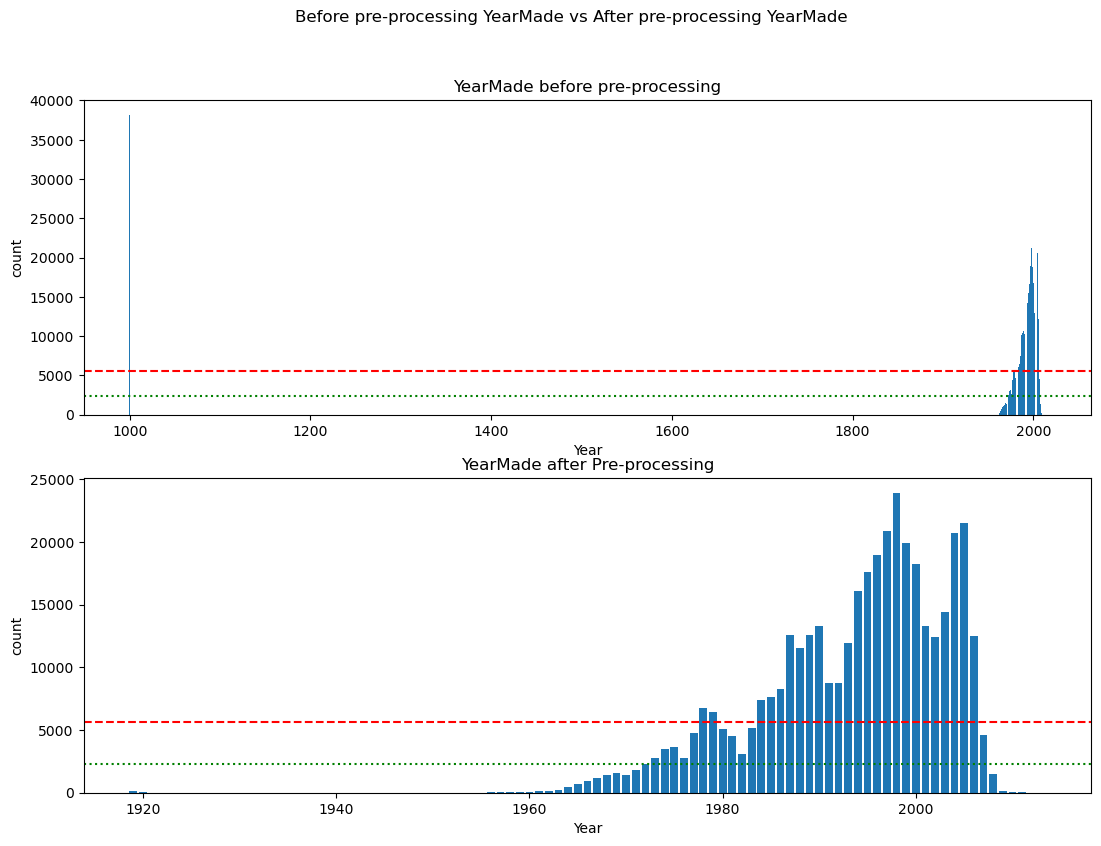

In [264]:
counts = train_df['YearMade'].value_counts().sort_index()

# Visualize "YearMade"
fig, axes = plt.subplots(figsize = (13, 9),
                        nrows = 2,
                        ncols = 1)
axes[0].bar(counts.index,
            counts.values)
axes[0].axhline(np.mean(train_df['YearMade'].value_counts()),
           linestyle = '--',
           c = 'red')
axes[0].axhline(np.median(train_df['YearMade'].value_counts()),
           linestyle = ':',
           c = 'green')
axes[0].set(title = "YearMade before pre-processing",
           xlabel = "Year",
           ylabel = "count")
#------------------------------------------------------------
counts = X_train['YearMade'].value_counts().sort_index()

axes[1].bar(X_train['YearMade'].sort_values().unique()[:-1],
            X_train['YearMade'].value_counts().sort_index())
axes[1].axhline(np.mean(X_train['YearMade'].value_counts()),
           linestyle = '--',
           c = 'red')
axes[1].axhline(np.median(X_train['YearMade'].value_counts()),
           linestyle = ':',
           c = 'green')
axes[1].set(title = "YearMade after Pre-processing",
           xlabel = "Year",
           ylabel = "count")

fig.suptitle("Before pre-processing YearMade vs After pre-processing YearMade");

### 6. Transforming Data type

6-1. **Ordinal Category:** 

    Blade_Width, Tire_Size, Undercarriage_Pad_Width, Stick_Length, Grouser_Type, ProductSize, UsageBand, Drive_System

### Checking the categories to see if there are things need to be fixed before applying "OrdinalEncoder"

In [265]:
ordinalCat_features = ['Blade_Width', 'Tire_Size', 'Undercarriage_Pad_Width', 'Stick_Length', 'Grouser_Type', 'ProductSize', 'UsageBand', 'Drive_System']

for col in ordinalCat_features:
    print(X_train[col].value_counts().sort_index())
    print("----------------------------")

Blade_Width
12'                    4968
13'                     329
14'                    9615
16'                     933
<12'                     91
None or Unspecified    9283
Name: count, dtype: int64
----------------------------
Tire_Size
10 inch                    3
10"                        8
13"                      766
14"                     8813
15.5                     607
15.5"                    457
17.5                    3932
17.5"                   1793
20.5                   15242
20.5"                    718
23.1"                     20
23.5                    8480
23.5"                    302
26.5                    4482
29.5                    2704
7.0"                      52
None or Unspecified    46339
Name: count, dtype: int64
----------------------------
Undercarriage_Pad_Width
14 inch                   49
15 inch                   33
16 inch                  460
18 inch                 1429
20 inch                 2652
22 inch                  133
24 inch  

In [266]:
# Fixing typos of "Tire_Size"

def tireSize_typo_fixing(df):     
    df['Tire_Size'] = df['Tire_Size'].replace({'10\"' : '10 inch',
                                                         '13\"' : '13 inch',
                                                         '14\"' : '14 inch',
                                                         '15.5' : '15.5 inch',
                                                         '15.5\"' : '15.5 inch',
                                                         '17.5' : '17.5 inch',
                                                         '17.5\"' : '17.5 inch',
                                                         '20.5' : '20.5 inch',
                                                         '20.5\"' : '20.5 inch',
                                                         '23.1\"' : '23.1 inch',
                                                         '23.5' : '23.5 inch',
                                                         '23.5\"' : '23.5 inch',
                                                         '26.5' : '26.5 inch',
                                                         '29.5' : '29.5 inch',
                                                         '7.0\"' : '7.0 inch'})     

In [267]:
print(X_train['Tire_Size'].value_counts().sort_index())

Tire_Size
10 inch                    3
10"                        8
13"                      766
14"                     8813
15.5                     607
15.5"                    457
17.5                    3932
17.5"                   1793
20.5                   15242
20.5"                    718
23.1"                     20
23.5                    8480
23.5"                    302
26.5                    4482
29.5                    2704
7.0"                      52
None or Unspecified    46339
Name: count, dtype: int64


In [268]:
tireSize_typo_fixing(X_train)
tireSize_typo_fixing(X_valid)

In [269]:
print(X_train['Tire_Size'].value_counts().sort_index())

Tire_Size
10 inch                   11
13 inch                  766
14 inch                 8813
15.5 inch               1064
17.5 inch               5725
20.5 inch              15960
23.1 inch                 20
23.5 inch               8782
26.5 inch               4482
29.5 inch               2704
7.0 inch                  52
None or Unspecified    46339
Name: count, dtype: int64


In [316]:
from sklearn.preprocessing import OrdinalEncoder

X_train_preprocessed = X_train.copy()
ordinalCat_features = ['Blade_Width', 'Tire_Size', 'Undercarriage_Pad_Width', 'Stick_Length', 'Grouser_Type', 'ProductSize', 'UsageBand', 'Drive_System']

encode_cat = {'Blade_Width' : ['None or Unspecified', "<12'", "12'", "13'", "14'", "16'", ],
              'Tire_Size' : ['None or Unspecified', '7.0 inch', '10 inch', '13 inch', '14 inch', '15.5 inch', '17.5 inch', '20.5 inch', '23.1 inch', '23.5 inch', '26.5 inch', '29.5 inch'],
              'Undercarriage_Pad_Width' : ['None or Unspecified', '14 inch', '15 inch', '16 inch', '18 inch', '20 inch', '22 inch', '24 inch', '25 inch', '26 inch', '27 inch', '28 inch', '30 inch', '31 inch', '31.5 inch', '32 inch', '33 inch', '34 inch', '36 inch'],
              'Stick_Length' : ['None or Unspecified', '6\' 3"','7\' 10"', '8\' 2"', '8\' 4"', '8\' 6"', '8\' 10"', '9\' 2"', '9\' 5"', '9\' 6"', '9\' 7"', '9\' 8"', '9\' 10"', '10\' 2"', '10\' 6"', '10\' 10"','11\' 0"', '11\' 10"',  '12\' 4"', '12\' 8"', '12\' 10"',  '13\' 7"', '13\' 9"', '13\' 10"','14\' 1"', '15\' 4"', '15\' 9"', '19\' 8"', '24\' 3"'],
              'Grouser_Type' : [ 'Single', 'Double', 'Triple'],
              'ProductSize': [ 'Mini', 'Small', 'Compact', 'Medium', 'Large / Medium', 'Large'] ,
              'UsageBand' : ['Low', 'Medium', 'High'],
              'Drive_System' :['No', 'Two Wheel Drive', 'Four Wheel Drive', 'All Wheel Drive']
          }
ordinal_encoder = OrdinalEncoder(categories = [encode_cat['Blade_Width'],
                                                   encode_cat['Tire_Size'],
                                                   encode_cat['Undercarriage_Pad_Width'],
                                                   encode_cat['Stick_Length'],
                                                   encode_cat['Grouser_Type'],
                                                   encode_cat['ProductSize'],
                                                   encode_cat['UsageBand'],
                                                   encode_cat['Drive_System']],                                     
                                    handle_unknown = "use_encoded_value",
                                    unknown_value = np.nan,
                                    encoded_missing_value = np.nan)

X_train_preprocessed[ordinalCat_features] = ordinal_encoder.fit_transform(X_train_preprocessed[ordinalCat_features])

print(ordinal_encoder.categories_)

[array(['None or Unspecified', "<12'", "12'", "13'", "14'", "16'"],
      dtype=object), array(['None or Unspecified', '7.0 inch', '10 inch', '13 inch', '14 inch',
       '15.5 inch', '17.5 inch', '20.5 inch', '23.1 inch', '23.5 inch',
       '26.5 inch', '29.5 inch'], dtype=object), array(['None or Unspecified', '14 inch', '15 inch', '16 inch', '18 inch',
       '20 inch', '22 inch', '24 inch', '25 inch', '26 inch', '27 inch',
       '28 inch', '30 inch', '31 inch', '31.5 inch', '32 inch', '33 inch',
       '34 inch', '36 inch'], dtype=object), array(['None or Unspecified', '6\' 3"', '7\' 10"', '8\' 2"', '8\' 4"',
       '8\' 6"', '8\' 10"', '9\' 2"', '9\' 5"', '9\' 6"', '9\' 7"',
       '9\' 8"', '9\' 10"', '10\' 2"', '10\' 6"', '10\' 10"', '11\' 0"',
       '11\' 10"', '12\' 4"', '12\' 8"', '12\' 10"', '13\' 7"', '13\' 9"',
       '13\' 10"', '14\' 1"', '15\' 4"', '15\' 9"', '19\' 8"', '24\' 3"'],
      dtype=object), array(['Single', 'Double', 'Triple'], dtype=object), array(['Mini

6-2. **Binary category:** 

Forks, Turbocharged, Blade_Extension, Pushblock, Scarifier, Grouser_Tracks, Backhoe_Mounting, Engine_Horsepower  


In [273]:
# Checking if there are something need to be fixed
binary_features = ['Forks', 'Turbocharged', 'Blade_Extension', 'Pushblock', 'Scarifier', 'Grouser_Tracks', 'Backhoe_Mounting', 'Engine_Horsepower']

for feature in binary_features:
    print(f"Missing values: {X_train_preprocessed[feature].isna().sum()}")
    print(X_train_preprocessed[feature].value_counts())
    print("----------------")

Missing values: 209048
Forks
None or Unspecified    178300
Yes                     13777
Name: count, dtype: int64
----------------
Missing values: 321991
Turbocharged
None or Unspecified    75211
Yes                     3923
Name: count, dtype: int64
----------------
Missing values: 375906
Blade_Extension
None or Unspecified    24692
Yes                      527
Name: count, dtype: int64
----------------
Missing values: 375906
Pushblock
None or Unspecified    19463
Yes                     5756
Name: count, dtype: int64
----------------
Missing values: 375895
Scarifier
None or Unspecified    12719
Yes                    12511
Name: count, dtype: int64
----------------
Missing values: 357763
Grouser_Tracks
None or Unspecified    40515
Yes                     2847
Name: count, dtype: int64
----------------
Missing values: 322453
Backhoe_Mounting
None or Unspecified    78652
Yes                       20
Name: count, dtype: int64
----------------
Missing values: 375906
Engine_Horsepower
No

In [274]:
X_train_preprocessed[binary_features] = X_train_preprocessed[binary_features].astype("category")

for feature in binary_features:
    if isinstance(X_train_preprocessed[feature].dtype, pd.CategoricalDtype):         

        # Add binary column to indicate whether sample had missing value
        X_train_preprocessed[feature + "_is_missing"] = pd.isnull(X_train_preprocessed[feature])

        # Turn categories into numbers and add +1            
        X_train_preprocessed[feature] = X_train_preprocessed[feature].cat.codes +1

        X_train_preprocessed[feature].fillna(0)    

In [275]:
for _ in binary_features:
    print(X_train_preprocessed[_].value_counts())
    print("...........................................")

X_train_preprocessed[binary_features].info()

Forks
0    209048
1    178300
2     13777
Name: count, dtype: int64
...........................................
Turbocharged
0    321991
1     75211
2      3923
Name: count, dtype: int64
...........................................
Blade_Extension
0    375906
1     24692
2       527
Name: count, dtype: int64
...........................................
Pushblock
0    375906
1     19463
2      5756
Name: count, dtype: int64
...........................................
Scarifier
0    375895
1     12719
2     12511
Name: count, dtype: int64
...........................................
Grouser_Tracks
0    357763
1     40515
2      2847
Name: count, dtype: int64
...........................................
Backhoe_Mounting
0    322453
1     78652
2        20
Name: count, dtype: int64
...........................................
Engine_Horsepower
0    375906
1     23937
2      1282
Name: count, dtype: int64
...........................................
<class 'pandas.DataFrame'>
RangeIndex: 401125 e

6-3. **Nominal Category:** 

Enclosure, Pad_Type, Stick, Transmission, Blade_Width, Hydraulics, Hydraulics_Flow, Ripper, Ride_Control, Tip_Control, Coupler, Track_Type, Thumb, Blade_Type, Travel_Controls, Differential_Type, Steering_Controls, ProductGroupDesc state, fiProductClassDesc

In [276]:
nominal_cat = ['Enclosure', 'Pad_Type', 'Stick', 'Transmission', 'Hydraulics', 'Hydraulics_Flow', 'Ripper',
               'Ride_Control', 'Tip_Control', 'Coupler', 'Track_Type', 'Thumb', 'Blade_Type', 'Travel_Controls', 'Differential_Type',
               'Steering_Controls', 'ProductGroupDesc', 'state',
              'Pattern_Changer', 'fiProductClassDesc']

# Checking if features lost

for feature in X_train_preprocessed.columns:
    if isinstance(X_train_preprocessed[feature].dtype, pd.StringDtype):
        if feature not in nominal_cat:
            print(feature)

6-4. Turn categorical variables into numbers and fill missing values

In [277]:
X_train_preprocessed[nominal_cat] = X_train_preprocessed[nominal_cat].astype("category")

for feature in nominal_cat:
    if isinstance(X_train_preprocessed[feature].dtype, pd.CategoricalDtype):         

        # Add binary column to indicate whether sample had missing value
        X_train_preprocessed[feature + "_is_missing"] = pd.isnull(X_train_preprocessed[feature])

        # Turn categories into numbers and add +1            
        X_train_preprocessed[feature] = X_train_preprocessed[feature].cat.codes +1

In [278]:
X_train_preprocessed[nominal_cat].info()

<class 'pandas.DataFrame'>
RangeIndex: 401125 entries, 0 to 401124
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   Enclosure           401125 non-null  int8 
 1   Pad_Type            401125 non-null  int8 
 2   Stick               401125 non-null  int8 
 3   Transmission        401125 non-null  int8 
 4   Hydraulics          401125 non-null  int8 
 5   Hydraulics_Flow     401125 non-null  int8 
 6   Ripper              401125 non-null  int8 
 7   Ride_Control        401125 non-null  int8 
 8   Tip_Control         401125 non-null  int8 
 9   Coupler             401125 non-null  int8 
 10  Track_Type          401125 non-null  int8 
 11  Thumb               401125 non-null  int8 
 12  Blade_Type          401125 non-null  int8 
 13  Travel_Controls     401125 non-null  int8 
 14  Differential_Type   401125 non-null  int8 
 15  Steering_Controls   401125 non-null  int8 
 16  ProductGroupDesc    401125 non-

In [327]:
def preprocess_data(df, X_train = True, X_valid = False):
    '''
    1. Converting saledate to datetime
    2. Sorting the data with saledate
    3. Enrich datetime features
    4. Dropping redundant features
    5. Fixing typos
    6. Transforming categorical variables into numeric representations
    '''

    # datetime
    df['saledate'] = pd.to_datetime(df['saledate'])
    df.sort_values(by = "saledate",
                        ignore_index=True,
                        inplace = True)
    df['saleYear'] = df['saledate'].dt.year
    df['saleMonth'] = df['saledate'].dt.month
    df['saleDay'] = df['saledate'].dt.day
    df['saleWeekday'] = df['saledate'].dt.dayofweek
    df['saleDayOfYear'] = df['saledate'].dt.dayofyear
    df.drop(['saledate'], axis = 1, inplace = True)

    # Dropping features
    df.drop(['fiModelDesc', 'fiBaseModel' , 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductGroup', 'Enclosure_Type', 'Coupler_System'],
        axis = 1,
       inplace = True)


    # Fixing typos
    # Replacing "AutoShift" to "Autoshift"
    df['Transmission'] = df['Transmission'].replace({'AutoShift' : 'Autoshift'})

    # Fixing Tire_size typos         
    df['Tire_Size'] = df['Tire_Size'].replace({'10\"' : '10 inch',
                                                         '13\"' : '13 inch',
                                                         '14\"' : '14 inch',
                                                         '15.5' : '15.5 inch',
                                                         '15.5\"' : '15.5 inch',
                                                         '17.5' : '17.5 inch',
                                                         '17.5\"' : '17.5 inch',
                                                         '20.5' : '20.5 inch',
                                                         '20.5\"' : '20.5 inch',
                                                         '23.1\"' : '23.1 inch',
                                                         '23.5' : '23.5 inch',
                                                         '23.5\"' : '23.5 inch',
                                                         '26.5' : '26.5 inch',
                                                         '29.5' : '29.5 inch',
                                                         '7.0\"' : '7.0 inch'})


    # The function to find the most frequent yearMade
    most_frequent_func = lambda lst : max(set(lst), key = lst.count)

    # replacing yearMade = 1000 to the most frequent yearMade by inferring ModelID
    model_yearMade= {}
    for model in df[df['YearMade'] == 1000]["ModelID"].unique():
        model_yearMade[model] = list(df[df["ModelID"] == model]["YearMade"])
        model_yearMade[model] = [item for item in model_yearMade[model] if item != 1000]

    for k, v in model_yearMade.items():
        if v == []:
            model_yearMade[k] = np.nan
        else:
            model_yearMade[k] = most_frequent_func(v)
            
    df["YearMade"] = df["YearMade"].replace(1000, np.nan)
    df["YearMade"] = df["YearMade"].fillna(df["ModelID"].map(model_yearMade))
    
    # Binary Features

    binary_features = ['Forks', 'Turbocharged', 'Blade_Extension', 'Pushblock', 'Scarifier', 'Grouser_Tracks', 'Backhoe_Mounting', 'Engine_Horsepower']
    df[binary_features] = df[binary_features].astype("category")

    for feature in binary_features:
        if isinstance(df[feature].dtype, pd.CategoricalDtype):         

            # Add binary column to indicate whether sample had missing value
            df[feature + "_is_missing"] = pd.isnull(df[feature])

            # Turn categories into numbers and add +1            
            df[feature] = df[feature].cat.codes +1

            df[feature].fillna(0)
     

    #  Nominal Features
    nominal_features = ['Enclosure', 'Pad_Type', 'Stick', 'Transmission', 'Hydraulics', 'Hydraulics_Flow', 'Ripper',
               'Ride_Control', 'Tip_Control', 'Coupler', 'Track_Type', 'Thumb', 'Blade_Type', 'Travel_Controls', 'Differential_Type',
               'Steering_Controls', 'ProductGroupDesc', 'state',
              'Pattern_Changer', 'fiProductClassDesc']

    df[nominal_features] = df[nominal_features].astype("category")

    for feature in nominal_features:
        if isinstance(df[feature].dtype, pd.CategoricalDtype):         

            # Add binary column to indicate whether sample had missing value
            df[feature + "_is_missing"] = pd.isnull(df[feature])

            # Turn categories into numbers and add +1            
            df[feature] = df[feature].cat.codes +1


    # Ordinal Features
    ordinalCat_features = ['Blade_Width', 'Tire_Size', 'Undercarriage_Pad_Width', 'Stick_Length', 'Grouser_Type', 'ProductSize', 'UsageBand', 'Drive_System']

    encode_cat = {'Blade_Width' : ['None or Unspecified', "<12'", "12'", "13'", "14'", "16'", ],
              'Tire_Size' : ['None or Unspecified', '7.0 inch', '10 inch', '13 inch', '14 inch', '15.5 inch', '17.5 inch', '20.5 inch', '23.1 inch', '23.5 inch', '26.5 inch', '29.5 inch'],
              'Undercarriage_Pad_Width' : ['None or Unspecified', '14 inch', '15 inch', '16 inch', '18 inch', '20 inch', '22 inch', '24 inch', '25 inch', '26 inch', '27 inch', '28 inch', '30 inch', '31 inch', '31.5 inch', '32 inch', '33 inch', '34 inch', '36 inch'],
              'Stick_Length' : ['None or Unspecified', '6\' 3"','7\' 10"', '8\' 2"', '8\' 4"', '8\' 6"', '8\' 10"', '9\' 2"', '9\' 5"', '9\' 6"', '9\' 7"', '9\' 8"', '9\' 10"', '10\' 2"', '10\' 6"', '10\' 10"','11\' 0"', '11\' 10"',  '12\' 4"', '12\' 8"', '12\' 10"',  '13\' 7"', '13\' 9"', '13\' 10"','14\' 1"', '15\' 4"', '15\' 9"', '19\' 8"', '24\' 3"'],
              'Grouser_Type' : [ 'Single', 'Double', 'Triple'],
              'ProductSize': [ 'Mini', 'Small', 'Compact', 'Medium', 'Large / Medium', 'Large'] ,
              'UsageBand' : ['Low', 'Medium', 'High'],
              'Drive_System' :['No', 'Two Wheel Drive', 'Four Wheel Drive', 'All Wheel Drive']
          }
    ordinal_encoder = OrdinalEncoder(categories = [encode_cat['Blade_Width'],
                                                   encode_cat['Tire_Size'],
                                                   encode_cat['Undercarriage_Pad_Width'],
                                                   encode_cat['Stick_Length'],
                                                   encode_cat['Grouser_Type'],
                                                   encode_cat['ProductSize'],
                                                   encode_cat['UsageBand'],
                                                   encode_cat['Drive_System']],                                     
                                    handle_unknown = "use_encoded_value",
                                    unknown_value = np.nan,
                                    encoded_missing_value = np.nan)
    # Shifting codes by adding 1
    for feature in ordinalCat_features:
        # Add binary column to indicate whether sample had missing value
        df[feature + "_is_missing"] = pd.isnull(df[feature])
        # Turn categories into numbers and add +1            
        df[feature] = df[feature] + 1
        df[feature] = df[feature].fillna(0)

    
    if X_train:
        X_train_preprocessed = df.copy()
        X_train_preprocessed[ordinalCat_features] = ordinal_encoder.fit_transform(X_train_preprocessed[ordinalCat_features])
        return X_train_preprocessed
        
    elif X_valid:
        X_valid_preprocessed = df.copy()        
        X_valid_preprocessed[ordinalCat_features] = ordinal_encoder.transform(X_valid_preprocessed[ordinalCat_features])
        return X_valid_preprocessed

    print(f"Ordinal Categories: {ordinal_encoder.categories_}")

In [330]:
# Split training data into features and targets
X_train = train_df.drop("SalePrice", axis = 1)
y_train = train_df["SalePrice"]

# Split validation data into features and targets
valid_sol_df = pd.read_csv("./data/ValidSolution.csv")
valid_df["SalePrice"] = valid_df["SalesID"].map(valid_sol_df.set_index("SalesID")["SalePrice"])

X_valid = valid_df.drop(["SalePrice"], axis = 1)
y_valid = valid_df["SalePrice"]

processed_valid = preprocess_data(X_valid, X_valid = True, X_train = False)

TypeError: operation 'add' not supported for dtype 'str' with object of type <class 'int'>

## Fitting a model on preprocessed training data

In [ ]:
# Checking the data type before fitting the model

X_train_preprocessed.info()

In [280]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_jobs = -1)
model.fit(X = X_train_preprocessed,
         y = y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [284]:
model.score(X_train_preprocessed,
           y_train)

0.9198405639464634

In [285]:
# Saving the model
import joblib

joblib.dump(value = model,
           filename = "./model/bulldozer_basemodel1" )

['./model/bulldozer_basemodel1']